# 4.6 NK cell lineage in the bone marrow microenvironment

Author: Xuezhu Sunny Wang

## Dataset 📊

- scRNA-seq of NK cell lineage

## Steps overview 📒

- Refine NK cell annotation based on marker gene expression
- Investigate proportion of NK cell subtypes changing with treatment and response
- Use ssGSEA to study the dysregulated pathways in patients with suboptimal treatment response
- Plot the expression and changes of marker genes of exhaustion in NK cells
- Export the fine-grained annotation of NK cells for the CellChat analysis
  

In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1_nkcell<-readRDS(file='sce1_nkcell.rds')

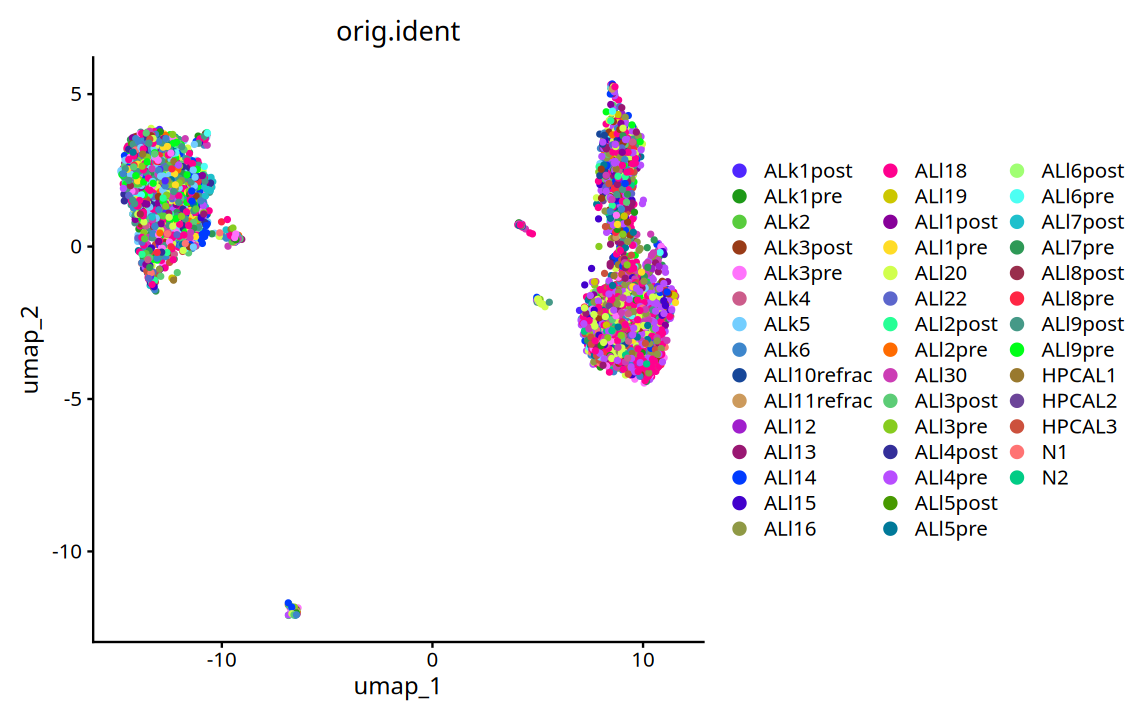

In [3]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_nkcell, pt.size=1,reduction = "umap", group.by = c("orig.ident"),label=F) 

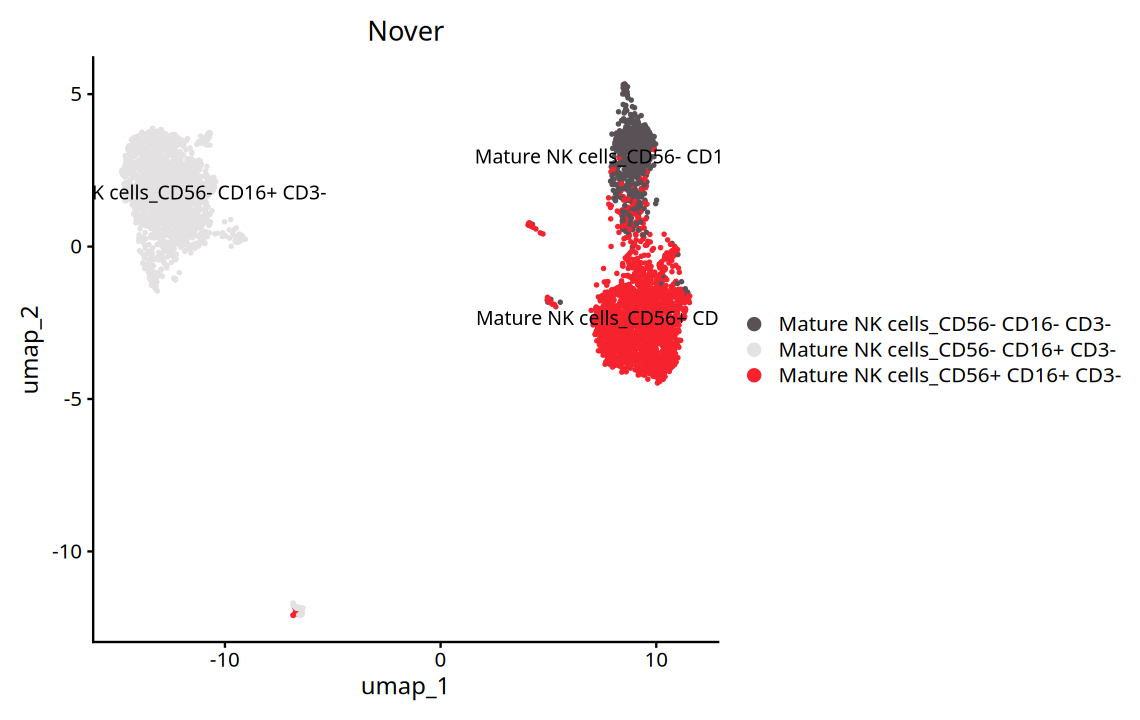

In [4]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_nkcell, pt.size=0.5,reduction = "umap", group.by = c("Nover"),label=T) 

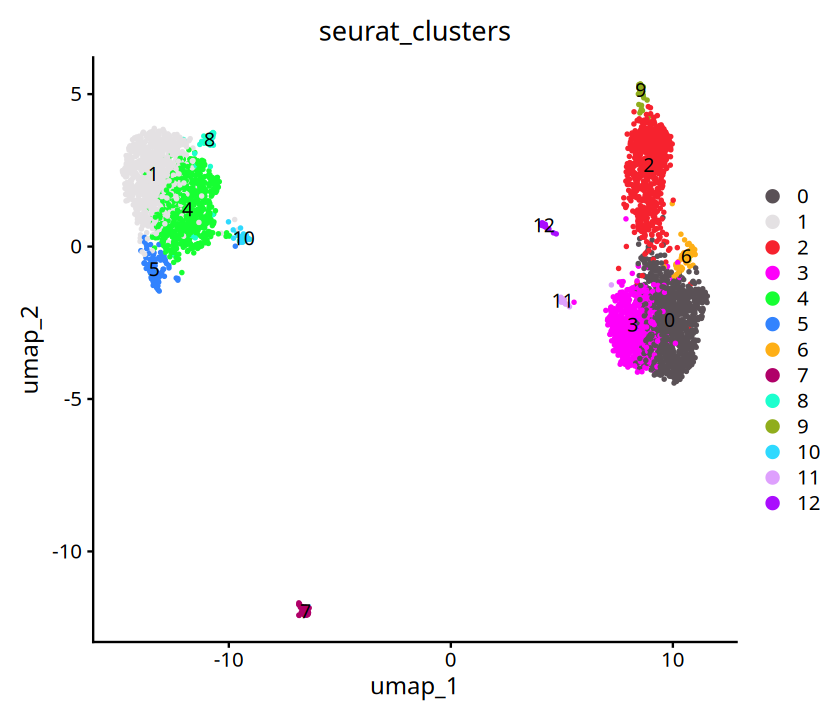

In [5]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=7)
DimPlot_scCustom(sce1_nkcell, pt.size=0.5,reduction = "umap", group.by = c("seurat_clusters"),label=T) 

In [6]:
sce1_nkcell

An object of class Seurat 
36601 features across 4245 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, UMAP, harmony, umap

In [7]:
Idents(sce1_nkcell)<-'Nover'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene<- c(
"FCGR3A", "NCAM1", "NCR1",'CD3', # Canonical NK cell surface markers (CD16, CD56, NKp46,CD3)
"TCF7","SELL","IL7R","XCL1","XCL2",#immature
"FCGR3A","CX3CR1","ZEB2","KLRD1", #mature
"PDCD1", "TIGIT", "LAG3", "HAVCR2", "CD96", "TIM3", # NK cell exhaustion/inhibitory checkpoint receptors
"KLRC1", "KLRG1", "KLRD1", # Inhibitory receptors and terminal differentiation markers
"IFNG", "TNF", 'IL10',# Effector cytokines
"PRF1", "GZMB", "GZMA", # Cytotoxic
"CXCR6", "CD69", "ITGA1", # Tissue-resident
"CD38"
) 


In [8]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_nkcell, features = unique(allgene), split.by = "seurat_clusters", scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
“The following requested variables were not found: CD3, TIM3”



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




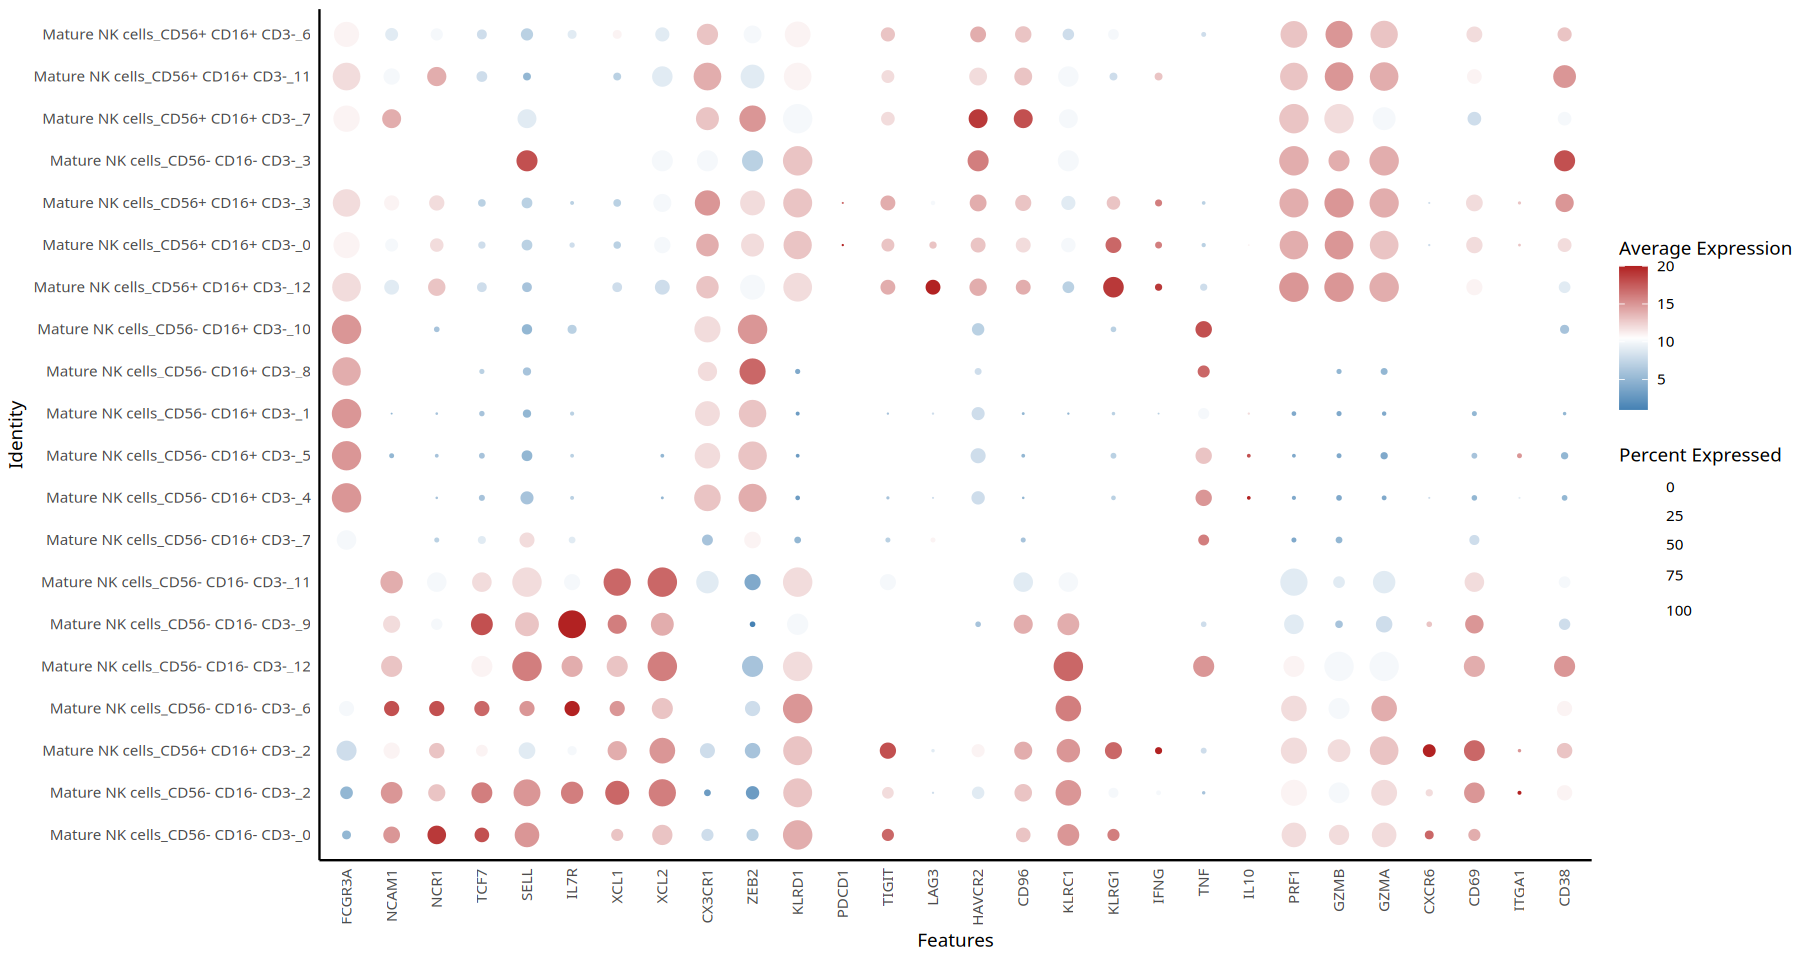

In [9]:
options(repr.plot.height=8,repr.plot.width=15)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [10]:
# Create a named vector: keys = original label, values = new label
sce1_nkcell@meta.data$Annotation<-paste(sce1_nkcell@meta.data$Nover, sce1_nkcell@meta.data$'seurat_clusters',sep='_')

replacements <- c(
  "Mature NK cells_CD56- CD16- CD3-_11" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_9" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_2" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_12" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_6" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_3" = "NK cells_CD56-_CD16+_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_3" = "NK cells_CD56-_CD16+_cytotoxic_terminal",
  "Mature NK cells_CD56+ CD16+ CD3-_0" = "NK cells_CD56-_CD16+_cytotoxic_terminal",
  "Mature NK cells_CD56+ CD16+ CD3-_12" = "NK cells_CD56-_CD16+_cytotoxic_terminal",
  "Mature NK cells_CD56+ CD16+ CD3-_6" = "NK cells_CD56-_CD16+_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_11" = "NK cells_CD56-_CD16+_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_7" = "NK cells_CD56+_CD16-_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_2" = "NK cells_CD56+_CD16-_transitional",
  "Mature NK cells_CD56- CD16- CD3-_0" = "NK cells_CD56+_CD16-_transitional",
  "Mature NK cells_CD56- CD16+ CD3-_10" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_8" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_1" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_7" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_5" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_4" = "NK cells_CD56-_CD16+_cytokine"
)

# Apply the replacement in one go:
sce1_nkcell@meta.data$Annotation <- replacements[sce1_nkcell@meta.data$Annotation]

# If any value not matched, return original:
sce1_nkcell@meta.data$Annotation[is.na(sce1_nkcell@meta.data$Annotation)] <- 
  paste(sce1_nkcell@meta.data$Nover, sce1_nkcell@meta.data$seurat_clusters, sep = "_")[is.na(sce1_nkcell@meta.data$Annotation)]


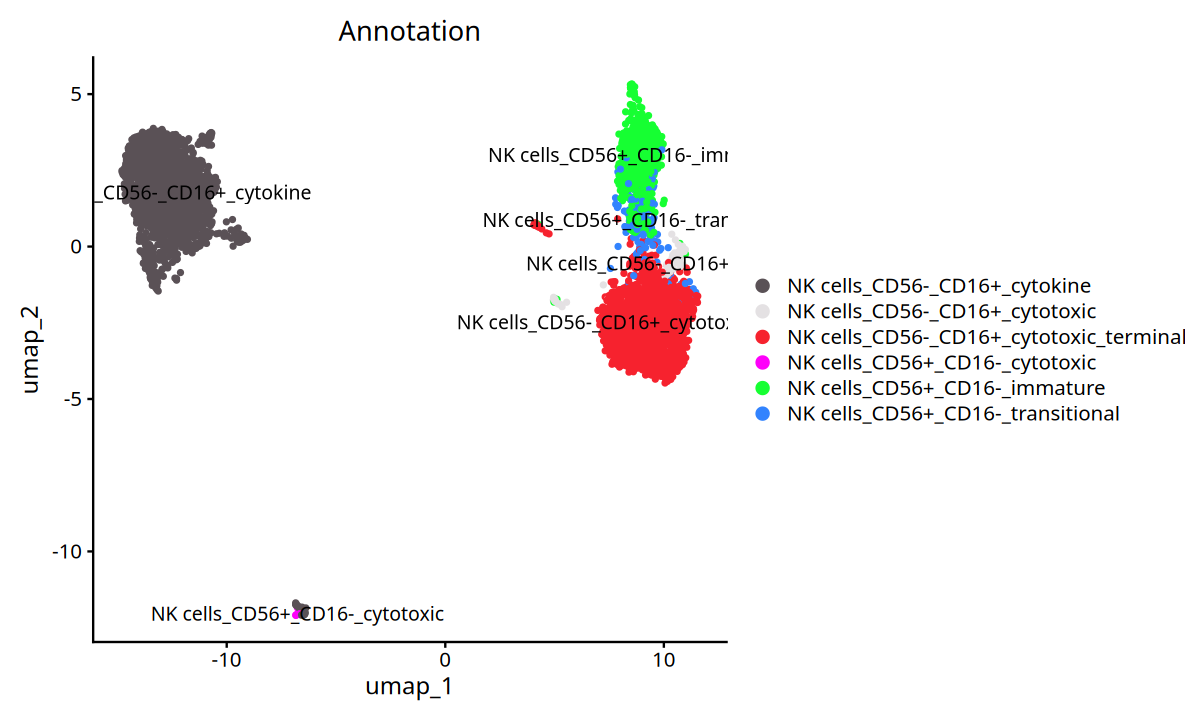

In [14]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=10)
DimPlot_scCustom(sce1_nkcell , pt.size=1,reduction = "umap", group.by = c("Annotation"),label=T) 

In [15]:
p <- DimPlot_scCustom(sce1_nkcell , pt.size=1,reduction = "umap", group.by = c("Annotation"),label=T) 
ggsave("FigS11a.pdf", plot = p, width = 10, height =6)


In [16]:
library(RColorBrewer)

Idents(sce1_nkcell)<-'Annotation'
# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_nkcell, features = unique(allgene),  scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
“The following requested variables were not found: CD3, TIM3”


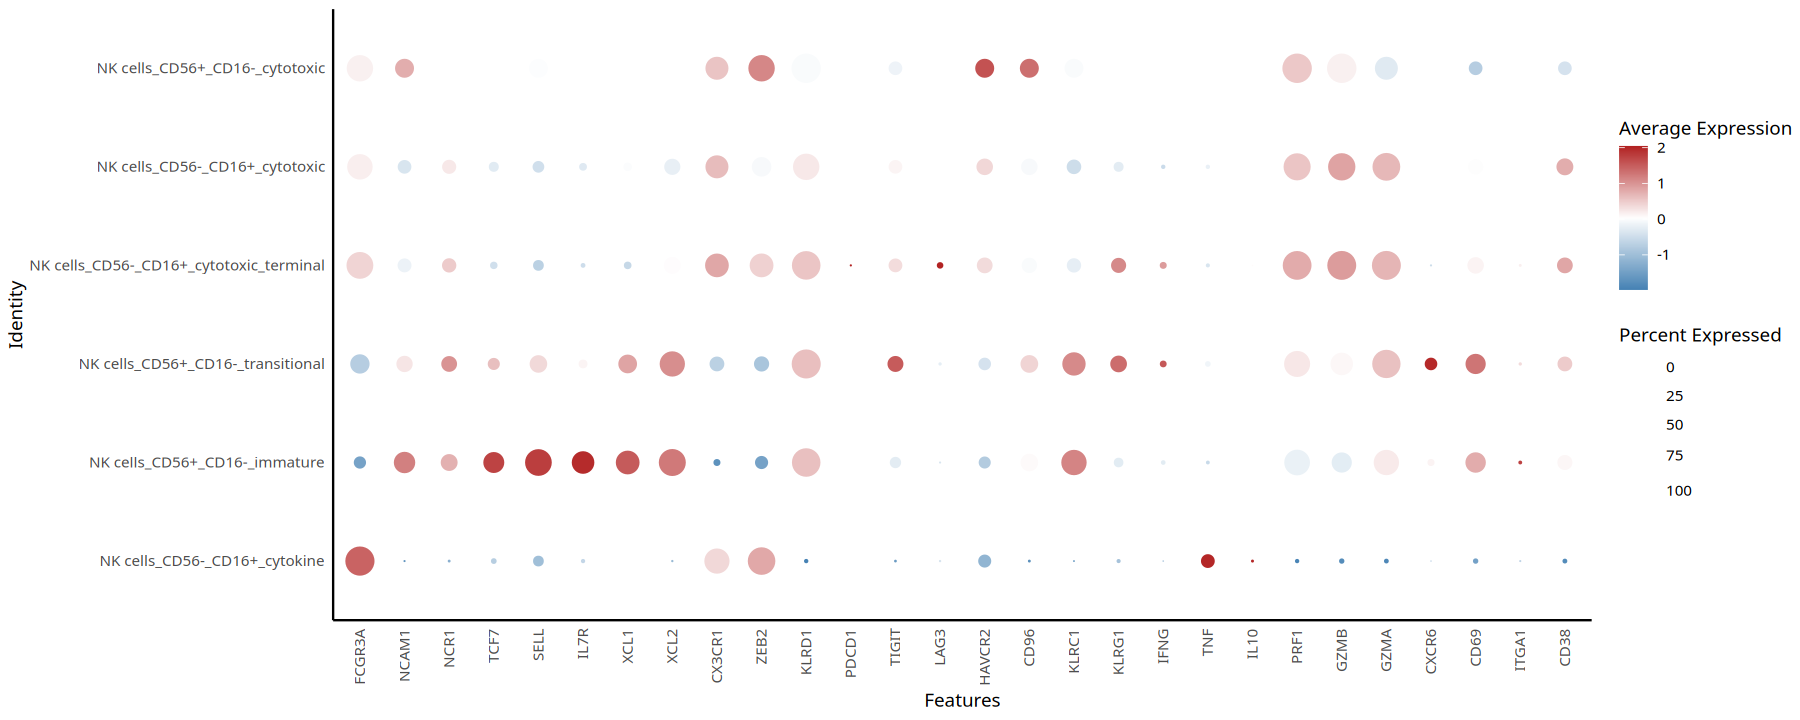

In [17]:
options(repr.plot.height=6,repr.plot.width=15)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [18]:
ggsave("FigS11b.pdf", plot = p, width = 10, height =6)

In [19]:
sce1_nkcell$label <- sce1_nkcell$orig.ident
sce1_nkcell$label <- ifelse(grepl("N1|N2", sce1_nkcell$label), "Normal", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl9pre|ALl8pre|ALl6pre|ALl30|ALl20|ALl19|ALl18|ALl14|ALl13|ALl1pre|ALk4|ALk1pre", sce1_nkcell$label), "AL_CR_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl9post|ALl8post|ALl6post|ALl1post|ALk1post", sce1_nkcell$label), "AL_CR_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl3pre|ALl22|ALk3pre|ALk2|HPCAL2", sce1_nkcell$label), "AL_VGPR_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALk3post|ALl3post", sce1_nkcell$label), "AL_VGPR_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl7pre|ALl12|ALk6|HPCAL1", sce1_nkcell$label), "AL_NR/SD_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl7post", sce1_nkcell$label), "AL_NR/SD_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl5pre|ALl4pre|ALl2pre|ALl16", sce1_nkcell$label), "AL_PR_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl5post|ALl4post|ALl2post|ALl11refrac|ALl10refrac", sce1_nkcell$label), "AL_PR_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("HPCAL3|ALl15|ALk5", sce1_nkcell$label), "AL_NotRecorded", sce1_nkcell$label)

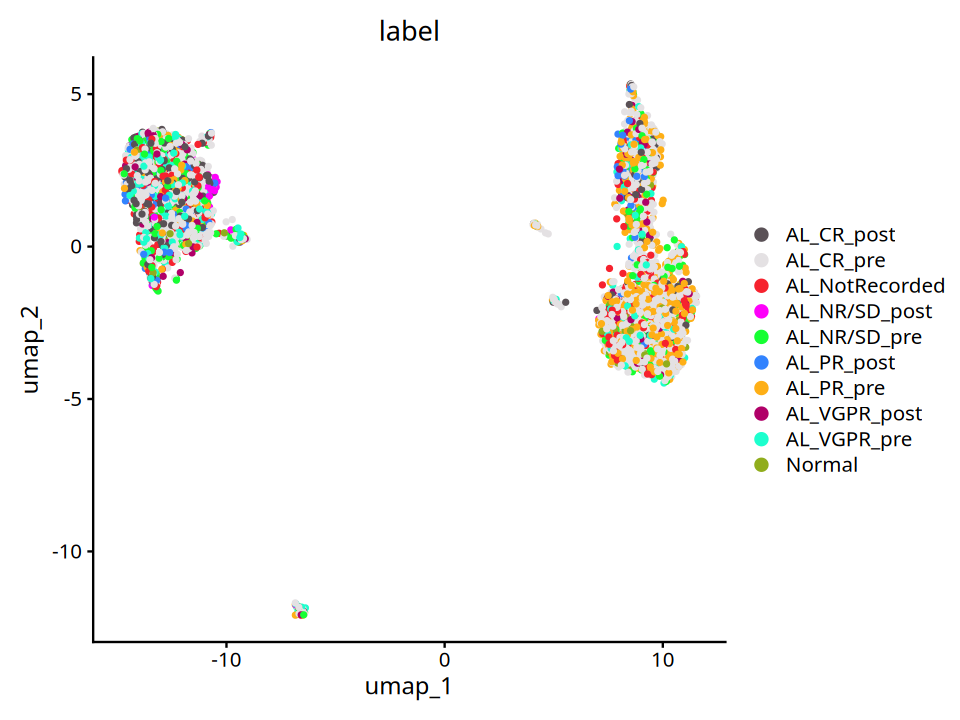

In [20]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_nkcell , pt.size=1,reduction = "umap", group.by = c("label"),label=F) 

# mismatched Pre:  0

# mismatched Post: 0

Warning message:
“There were 4 warnings in `mutate()`.
The first warning was:
ℹ In argument: `pval = ifelse(...)`.
ℹ In row 6.
Caused by warning in `chisq.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”


# A tibble: 36 × 6
   response celltype                               pre  post      pval      padj
   <fct>    <fct>                                <int> <int>     <dbl>     <dbl>
 1 AL_CR    NK cells_CD56-_CD16+_cytotoxic_term…   832    23 1.73e-168 3.98e-167
 2 AL_PR    NK cells_CD56-_CD16+_cytotoxic_term…   370     7 5.39e- 78 6.20e- 77
 3 AL_CR    NK cells_CD56-_CD16+_cytokine          613   256 9.30e- 34 7.13e- 33
 4 AL_NR/SD NK cells_CD56-_CD16+_cytokine          190    30 3.96e- 27 2.28e- 26
 5 AL_CR    NK cells_CD56+_CD16-_immature          213    45 1.33e- 25 6.12e- 25
 6 AL_NR/SD NK cells_CD56-_CD16+_cytotoxic_term…    84     2 9.38e- 19 3.59e- 18
 7 AL_PR    NK cells_CD56+_CD16-_immature          138    29 3.32e- 17 1.09e- 16
 8 AL_VGPR  NK cells_CD56-_CD16+_cytokine          228    84 3.57e- 16 1.03e- 15
 9 AL_NR/SD NK cells_CD56+_CD16-_immature           57     0 4.36e- 14 1.11e- 13
10 AL_VGPR  NK cells_CD56-_CD16+_cytotoxic_term…    88    28 2.53e-  8 5.83e-  8
11 AL_CR 

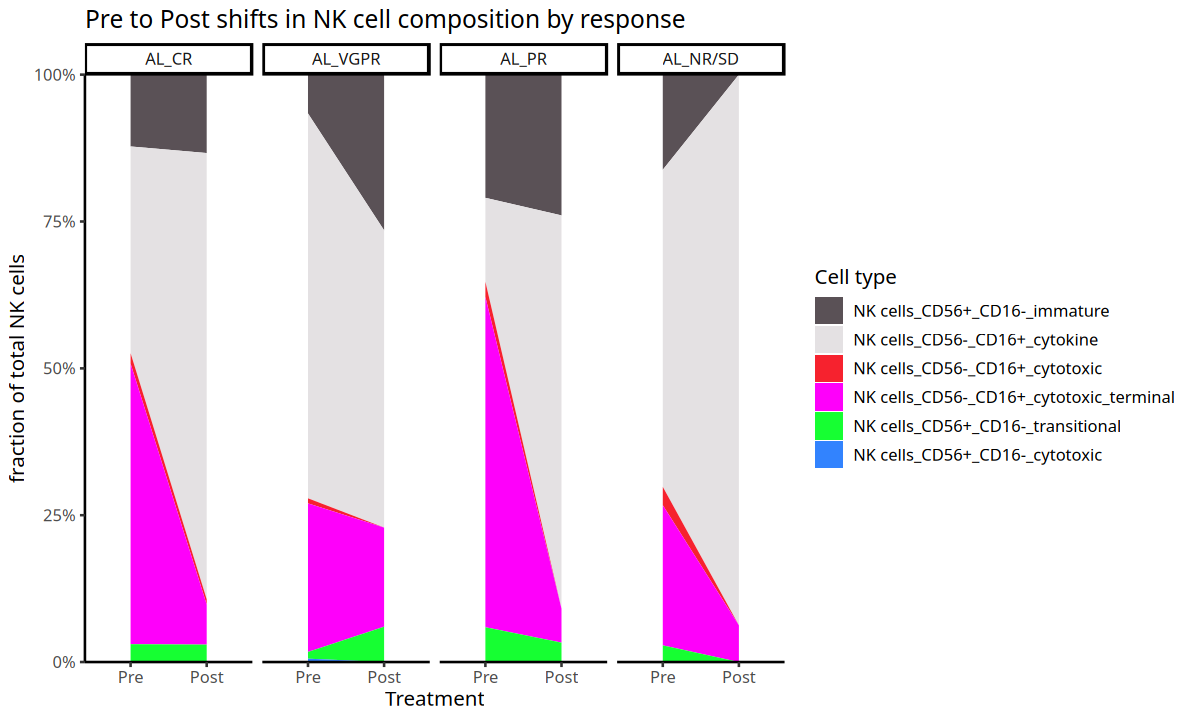

In [21]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(scCustomize)

Idents(sce1_nkcell) <- "Annotation"
ct_lvls <- levels(sce1_nkcell)
ct_cols <- setNames(
  scCustomize::DiscretePalette_scCustomize(length(ct_lvls), palette = "polychrome"),
  ct_lvls
)

# --- 0) Clean the label column (quotes, spaces, smart quotes) ---
sce1_nkcell$label <- as.character(sce1_nkcell$label)
sce1_nkcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_nkcell$label)

# --- 1) Build md with anchored matching ---
md <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label)  # defensive
  ) %>%
  transmute(
    celltype  = Annotation,
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ "Other"
    ),
    label_clean = label_clean
  )

# --- 2) Sanity checks ---
# Any cells flagged as Pre that do NOT end with _pre ?
bad_pre  <- md %>% filter(treatment == "Pre"  & !grepl("(_pre)$",  label_clean, perl = TRUE))
bad_post <- md %>% filter(treatment == "Post" & !grepl("(_post)$", label_clean, perl = TRUE))
message("# mismatched Pre:  ", nrow(bad_pre))
message("# mismatched Post: ", nrow(bad_post))
# If you see non-zero here, print some examples:
if (nrow(bad_pre) > 0 || nrow(bad_post) > 0) {
  print(head(unique(c(bad_pre$label_clean, bad_post$label_clean)), 10))
}

# --- 3) Composition per response × treatment (as before) ---
comp <- md %>%
  count(response, treatment, celltype, name = "n") %>%
  group_by(response, treatment) %>%
  mutate(frac = n / sum(n)) %>%
  ungroup() %>%
  complete(response, treatment, celltype, fill = list(n = 0, frac = 0))

comp$celltype  <- factor(comp$celltype,  levels = ct_lvls)
comp$treatment <- factor(comp$treatment, levels = c("Pre","Post","Other"))

# --- 4) Plot (skip Normal and AL_NotRecorded only in the plot) ---
options(repr.plot.height = 6, repr.plot.width = 10)

# Force the facet order
comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","AL_NotRecorded","Normal"))

p <- ggplot(
  comp %>%
    filter(treatment %in% c("Pre", "Post"),
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = treatment, y = frac, fill = celltype, group = celltype)
) +
  geom_area(stat = "identity", position = "stack") +
  facet_wrap(~response, nrow = 1) +   # one row, fixed order
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  labs(y = "fraction of total NK cells", x = "Treatment", fill = "Cell type",
       title = "Pre to Post shifts in NK cell composition by response") +
  scale_fill_manual(values = ct_cols) +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p)



# --- 5) Stats (unchanged) ---
chisq_results <- comp %>%
  filter(treatment %in% c("Pre","Post")) %>%
  group_by(response, celltype) %>%
  summarise(
    pre  = sum(n[treatment == "Pre"]),
    post = sum(n[treatment == "Post"]),
    .groups="drop"
  ) %>%
  rowwise() %>%
  mutate(pval = ifelse((pre+post) > 0,
                       chisq.test(c(pre, post), p = c(0.5, 0.5))$p.value,
                       NA_real_)) %>%
  ungroup() %>%
  mutate(padj = p.adjust(pval, method="BH")) %>%
  arrange(padj)

chisq_results %>% print(n = 20)


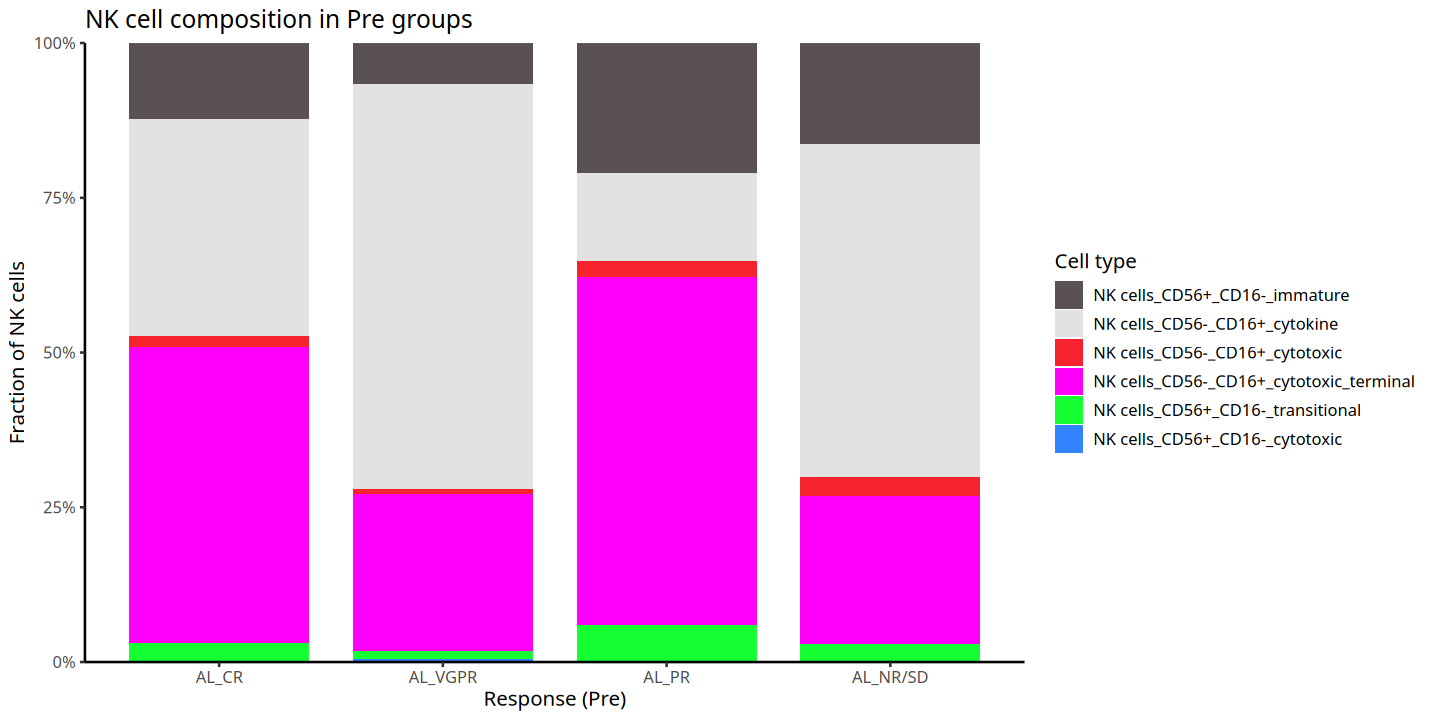

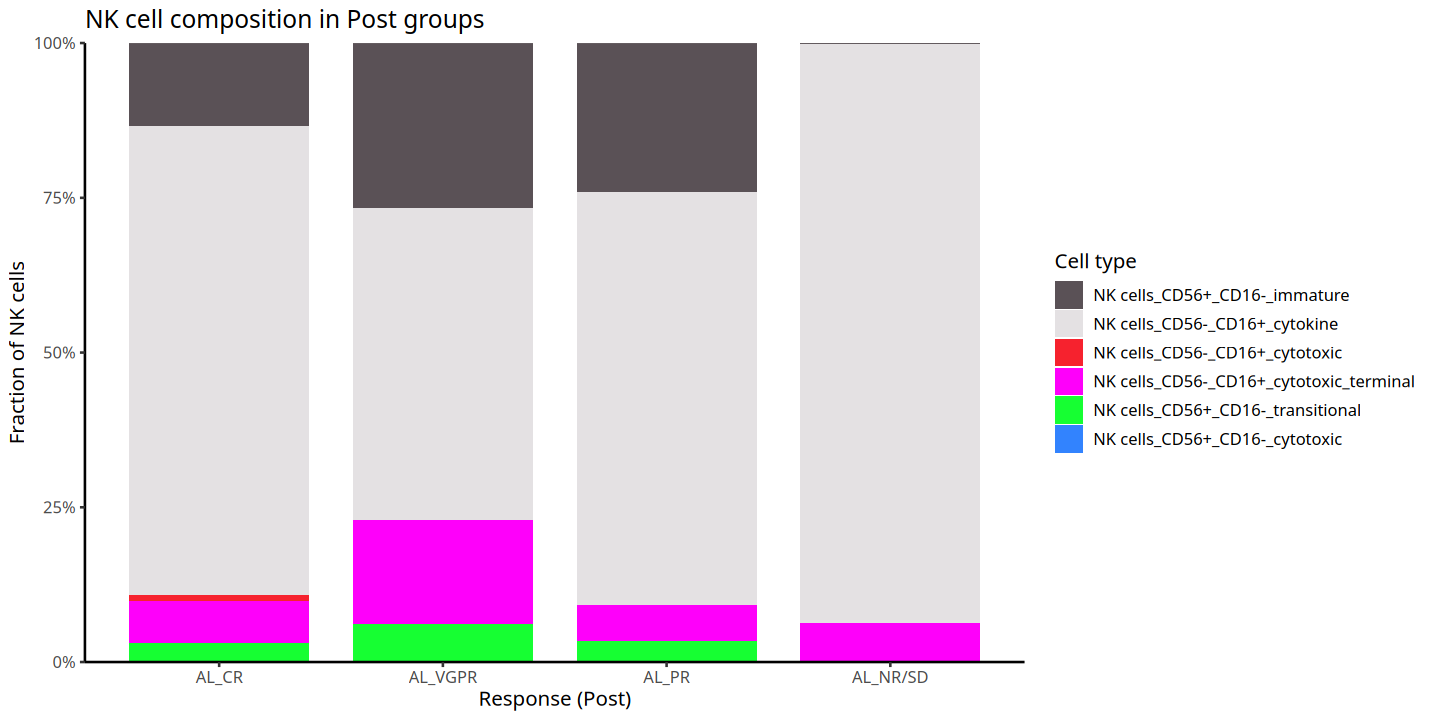

In [22]:
# --- Stacked bar plot for Pre groups ---
options(repr.plot.height = 6, repr.plot.width = 12)

comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","Normal", "AL_NotRecorded"))

p_pre <- ggplot(
  comp %>%
    filter(treatment == "Pre",
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Pre)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition in Pre groups") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_pre)

# --- Stacked bar plot for Post groups ---
p_post <- ggplot(
  comp %>%
    filter(treatment == "Post",
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Post)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition in Post groups") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_post)


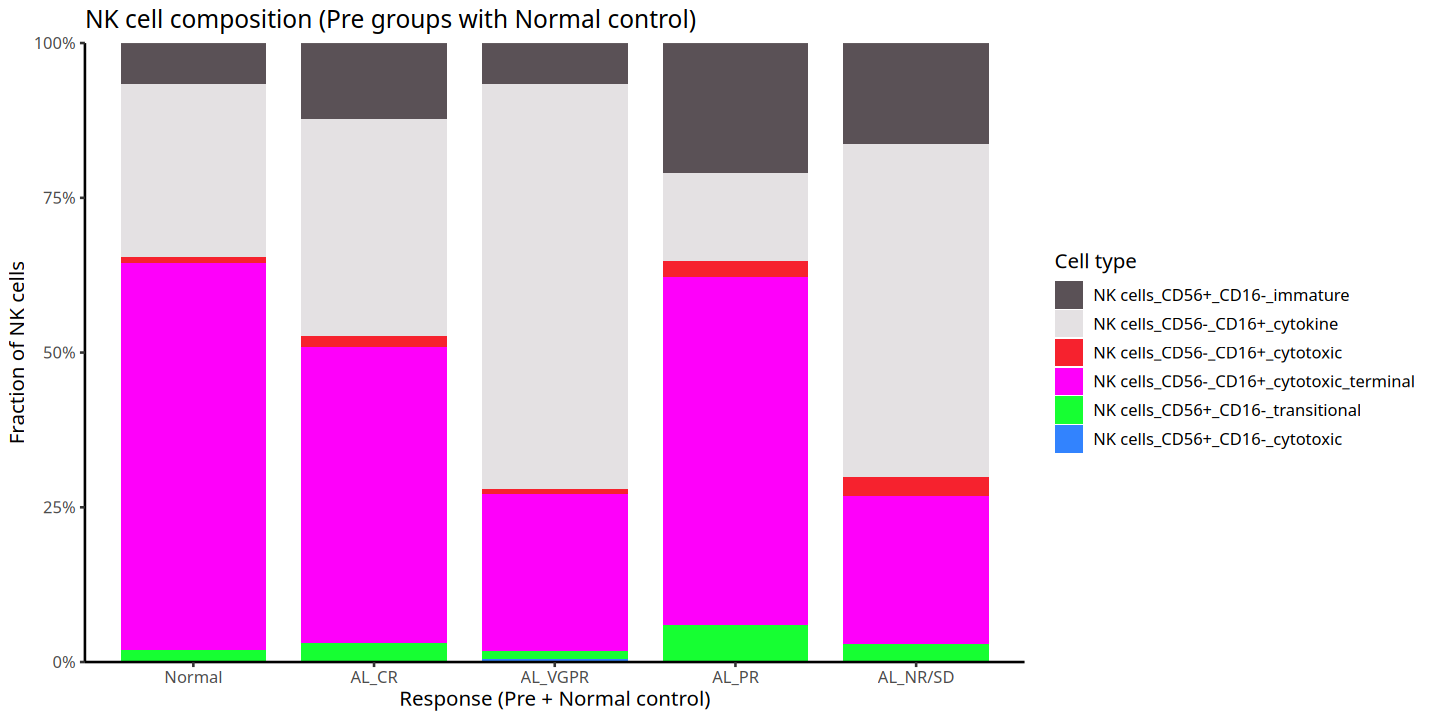

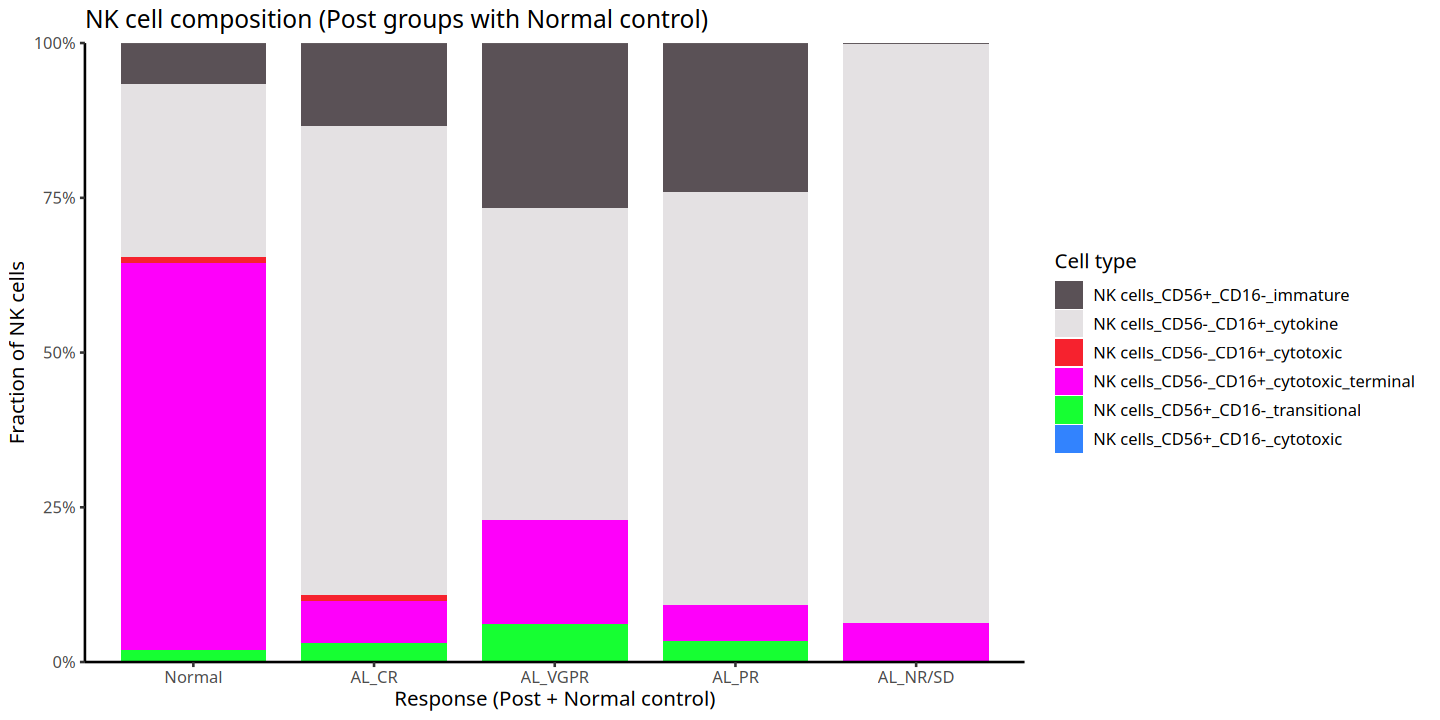

In [23]:
library(dplyr)
library(ggplot2)
library(scales)

# --- Ensure consistent response order ---
comp$response <- factor(
  comp$response,
  levels = c("Normal", "AL_NotRecorded", "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")
)

# --- 1) Collapse Normal group (no treatment) ---
normal_bar <- comp %>%
  filter(response == "Normal") %>%
  group_by(celltype) %>%
  summarise(frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  mutate(response = "Normal") %>%
  # Ensure Normal sums to 1 across celltypes
  mutate(frac = frac / sum(frac, na.rm = TRUE))

# --- 2) Pre dataset: keep only Pre rows + Normal bar ---
comp_pre_dat <- comp %>%
  filter(treatment == "Pre",
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  select(response, celltype, frac)

comp_pre_dat <- bind_rows(
  normal_bar,    # Normal has no treatment
  comp_pre_dat
) %>%
  # Normalize within each response so each stacked bar = 100%
  group_by(response) %>%
  mutate(frac = frac / sum(frac, na.rm = TRUE)) %>%
  ungroup()

# --- 3) Post dataset: keep only Post rows + Normal bar ---
comp_post_dat <- comp %>%
  filter(treatment == "Post",
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  select(response, celltype, frac)

comp_post_dat <- bind_rows(
  normal_bar,    # Normal has no treatment
  comp_post_dat
) %>%
  # Normalize within each response so each stacked bar = 100%
  group_by(response) %>%
  mutate(frac = frac / sum(frac, na.rm = TRUE)) %>%
  ungroup()

# (Keep your plotting code unchanged)


# --- 4) Fix factor levels again ---
comp_pre_dat$response  <- factor(comp_pre_dat$response,  levels = levels(comp$response))
comp_post_dat$response <- factor(comp_post_dat$response, levels = levels(comp$response))

# --- 5) Stacked bar plot for Pre groups + Normal ---
options(repr.plot.height = 6, repr.plot.width = 12)

p_pre <- ggplot(
  comp_pre_dat,
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Pre + Normal control)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition (Pre groups with Normal control)") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_pre)

# --- 6) Stacked bar plot for Post groups + Normal ---
p_post <- ggplot(
  comp_post_dat,
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Post + Normal control)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition (Post groups with Normal control)") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_post)


In [24]:
sce1_nkcell@meta.data$barcode<-rownames(sce1_nkcell@meta.data)
label<-sce1_nkcell@meta.data[,c('barcode','Annotation')]
write.csv(label,file='NKcell.noverlabel.csv')

In [25]:
# 0) Clean labels and derive response/treatment per cell (anchored)
sce1_nkcell$label <- as.character(sce1_nkcell$label)
sce1_nkcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_nkcell$label)

meta_df <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label),
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),
    celltype  = Annotation
  )


# Attach for convenience
sce1_nkcell$response  <- meta_df$response
sce1_nkcell$treatment <- meta_df$treatment


In [26]:
# 1) Keep only valid Pre/Post cells for expression averaging
valid <- with(meta_df, !is.na(response) & !is.na(treatment))
sce_expr <- subset(sce1_nkcell, cells = rownames(meta_df)[valid])

# 2) Define markers (gene symbols in RNA assay)
marker_map <- c(TIGIT='TIGIT',HAVCR2='HAVCR2',CD96='CD96',KLRG1='KLRG1',LAG3='LAG3')
features_to_use <- unique(unname(marker_map))

# 3) Build grouping key for averaging: response|treatment|celltype
sce_expr$resp_treat_ct <- with(sce_expr@meta.data, paste(response, treatment, Annotation, sep = "|"))



In [27]:
avg <- AverageExpression(
  sce_expr,
  features = features_to_use,
  group.by = "resp_treat_ct",
  assays = "RNA",
  slot = "data"
)$RNA
# rows = genes, cols = "response|treatment|celltype"


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


In [28]:
# 4) Tidy to long + map gene -> marker
df_expr <- as.data.frame(avg) %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "grp", values_to = "expr") %>%
  separate(grp, into = c("response","treatment","celltype"), sep = "\\|", fill = "right") %>%
  filter(!is.na(response), !is.na(treatment), !is.na(celltype)) %>%
  mutate(marker = names(marker_map)[match(gene, marker_map[marker_map %in% gene])]) %>%
  filter(!is.na(marker))

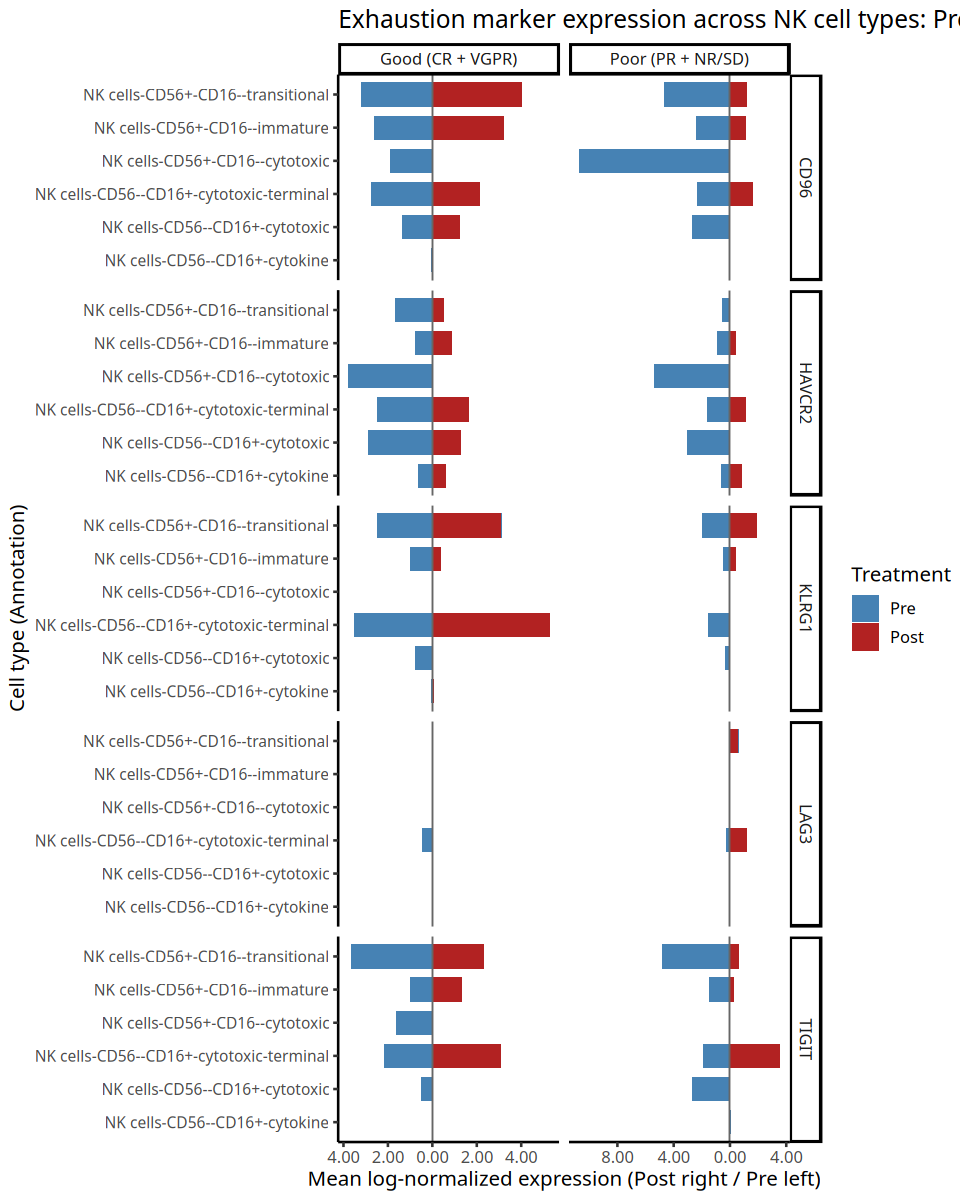

In [29]:
# 5) Prepare diverging values (Pre negative, Post positive) + response grouping
df_plot <- df_expr %>%
  mutate(
    response  = factor(response, levels = c("AL-CR","AL-VGPR","AL-PR","AL-NR/SD")),
    treatment = factor(treatment, levels = c("Pre","Post")),
    celltype  = celltype,
    value     = ifelse(treatment == "Post", expr, -expr),
    response_group = case_when(
      response %in% c("AL-CR","AL-VGPR")   ~ "Good",
      response %in% c("AL-PR","AL-NR/SD")  ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  # Omit anything not mapped (e.g., Normal / AL_NotRecorded) only in the plot
  filter(!is.na(response_group)) %>%
  mutate(response_group = factor(response_group, levels = c("Good","Poor")))

# Labels for the grouped facet
grp_labeller <- as_labeller(c(Good = "Good (CR + VGPR)", Poor = "Poor (PR + NR/SD)"))

options(repr.plot.height = 10, repr.plot.width = 8)

# 6) Plot: symmetrical (diverging) horizontal barplot, *transposed facets*
p_diverge <- ggplot(df_plot, aes(x = celltype, y = value, fill = treatment)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0, linewidth = 0.4, color = "grey40") +
  coord_flip() +
  facet_grid(
    rows = vars(marker),               # markers on rows
    cols = vars(response_group),       # Good/Poor on columns
    labeller = labeller(response_group = grp_labeller),
    scales = "free_x"
  ) +
  scale_y_continuous(labels = function(x) sprintf("%.2f", abs(x))) +
  scale_fill_manual(values = c("Pre" = "steelblue", "Post" = "firebrick")) +
  labs(
    x = "Cell type (Annotation)",
    y = "Mean log-normalized expression (Post right / Pre left)",
    fill = "Treatment",
    title = "Exhaustion marker expression across NK cell types: Pre vs Post by response group"
  ) +
  theme_classic(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 9),
    legend.position = "right"
  )

print(p_diverge)


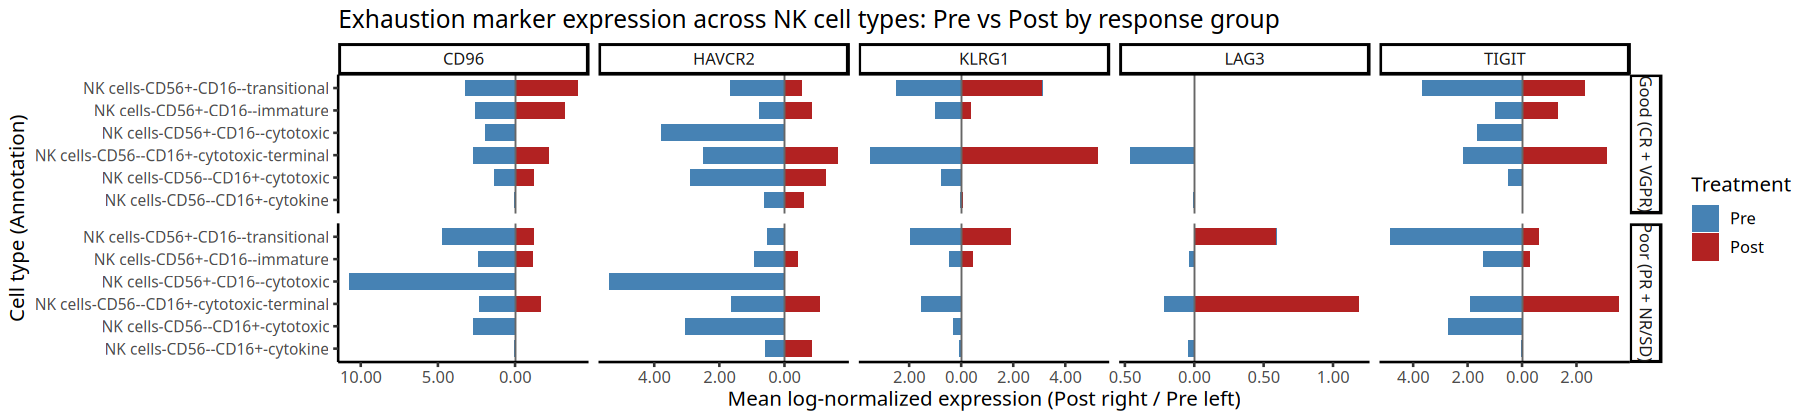

In [31]:
# Group responses (CR/VGPR -> Good; PR/NR/SD -> Poor)
df_plot <- df_expr %>%
  mutate(
    response  = factor(response, levels = c("AL-CR","AL-VGPR","AL-PR","AL-NR/SD")),
    treatment = factor(treatment, levels = c("Pre","Post")),
    value     = ifelse(treatment == "Post", expr, -expr),
    response_group = case_when(
      response %in% c("AL-CR","AL-VGPR")  ~ "Good",
      response %in% c("AL-PR","AL-NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(response_group)) %>%
  mutate(response_group = factor(response_group, levels = c("Good","Poor")))

grp_labeller <- as_labeller(c(Good = "Good (CR + VGPR)", Poor = "Poor (PR + NR/SD)"))

options(repr.plot.height = 3.5, repr.plot.width = 15)

p_diverge <- ggplot(df_plot, aes(x = celltype, y = value, fill = treatment)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0, linewidth = 0.4, color = "grey40") +
  coord_flip() +
  facet_grid(
    rows = vars(response_group),  # <-- Good/Poor as rows
    cols = vars(marker),          # <-- markers as columns
    labeller = labeller(response_group = grp_labeller),
    scales = "free_x"
  ) +
  scale_y_continuous(labels = function(x) sprintf("%.2f", abs(x))) +
  scale_fill_manual(values = c("Pre" = "steelblue", "Post" = "firebrick")) +
  labs(
    x = "Cell type (Annotation)",
    y = "Mean log-normalized expression (Post right / Pre left)",
    fill = "Treatment",
    title = "Exhaustion marker expression across NK cell types: Pre vs Post by response group"
  ) +
  theme_classic(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 9),
    legend.position = "right"
  )

print(p_diverge)


In [32]:
ggsave("Fig6i.pdf", plot = p_diverge, width = 15, height =3.5)


In [33]:
# Summarize by Pre vs Post
df_summary <- df_expr %>%
  group_by(response, celltype, marker, treatment) %>%
  summarise(mean_expr = mean(expr, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = treatment, values_from = mean_expr) %>%
  mutate(
    log2FC = log2((Post + 1e-6) / (Pre + 1e-6) )  # add small offset to avoid division by 0
  ) %>%
  filter(!response %in% c("Normal","AL_NotRecorded"))


In [34]:
# --- Packages ---
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(purrr)
})

# ========= CONFIGURE =========
celltype_col  <- "Annotation"
response_col  <- "response"
treat_col     <- "treatment"   # expects "Pre"/"Post"
sample_col    <- "orig.ident"
per_sample_mean <- TRUE

# Desired row order (and Pre reference):
response_levels <- c("AL_CR","AL_VGPR","AL_PR","AL_NR/SD")
ref_response    <- "AL_CR"   # compare other Pre groups vs CR (reference)

eps <- 1e-6
lfc_strong <- 1.0    # >= 2x
lfc_moder  <- 0.585  # >= 1.5x

# ----------- DATA PREP -----------
md <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  transmute(
    celltype  = .data[[celltype_col]],
    response  = .data[[response_col]],
    treatment = .data[[treat_col]],
    sample_id = .data[[sample_col]]
  ) %>%
  filter(!is.na(celltype), !is.na(response), !is.na(treatment), !is.na(sample_id)) %>%
  mutate(
    treatment = dplyr::recode(treatment, "pre"="Pre", "post"="Post", "PRE"="Pre", "POST"="Post"),
    treatment = factor(treatment, levels = c("Pre","Post")),
    celltype  = factor(celltype),
    response  = factor(response, levels = response_levels)  # enforce row order
  )

# ----------- FRACTIONS PER SAMPLE -----------
frac_by_sample <- md %>%
  count(response, treatment, sample_id, celltype, name = "n_ct") %>%
  group_by(response, treatment, sample_id) %>%
  mutate(frac = n_ct / sum(n_ct)) %>%
  ungroup()

# Average across samples (response × treatment × celltype)
frac_rtct <- frac_by_sample %>%
  group_by(response, treatment, celltype) %>%
  summarize(frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  tidyr::complete(response = response_levels, treatment, celltype, fill = list(frac = 0)) %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- FOLD CHANGE (Post vs Pre) -> symbols on Post panel -----------
frac_wide <- frac_rtct %>%
  select(response, treatment, celltype, frac) %>%
  pivot_wider(names_from = treatment, values_from = frac, values_fill = 0)

change_tbl <- frac_wide %>%
  mutate(
    lfc = log2((Post + eps) / (Pre + eps)),
    change_sym = case_when(
      lfc >=  lfc_strong ~ "++",
      lfc >=  lfc_moder  ~ "+",
      lfc <= -lfc_strong ~ "--",
      lfc <= -lfc_moder  ~ "-",
      TRUE               ~ "+/-"
    )
  )

annot_post <- frac_rtct %>%
  filter(treatment == "Post") %>%
  left_join(change_tbl %>% select(response, celltype, change_sym),
            by = c("response","celltype")) %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- PRE-GROUP SIGNIFICANCE vs CR (reference) -> "*" on Pre panel -----------
# Build per-(celltype,response) lists of sample fractions for Pre only
pre_lists <- frac_by_sample %>%
  filter(treatment == "Pre") %>%
  group_by(celltype, response) %>%
  summarize(vals = list(frac), .groups = "drop")

# Get reference vectors (CR) per celltype
ref_tbl <- pre_lists %>%
  filter(response == ref_response) %>%
  transmute(celltype, ref_vals = vals)

# For each (celltype, response != CR), Wilcoxon rank-sum vs CR; BH adjust within celltype
stat_pre <- pre_lists %>%
  left_join(ref_tbl, by = "celltype") %>%
  filter(response != ref_response) %>%
  mutate(
    p_value = map2_dbl(vals, ref_vals, ~{
      x <- .x; y <- .y
      if (length(x) > 0 && length(y) > 0) {
        suppressWarnings(tryCatch(wilcox.test(unlist(x), unlist(y))$p.value,
                                  error = function(e) NA_real_))
      } else NA_real_
    })
  ) %>%
  group_by(celltype) %>%
  mutate(p_adj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(star = ifelse(!is.na(p_adj) & p_adj < 0.05, "*", "")) %>%
  select(celltype, response, star)

# Attach stars to the Pre tiles only
annot_pre <- frac_rtct %>%
  filter(treatment == "Pre") %>%
  left_join(stat_pre, by = c("celltype","response")) %>%
  filter(!is.na(star), star != "") %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- Order celltypes (columns) by overall mean abundance -----------
ct_order <- frac_rtct %>%
  group_by(celltype) %>%
  summarize(m = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(m)) %>% pull(celltype)
frac_rtct$celltype <- factor(frac_rtct$celltype, levels = ct_order)
annot_post$celltype <- factor(annot_post$celltype, levels = ct_order)
annot_pre$celltype  <- factor(annot_pre$celltype,  levels = ct_order)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message 

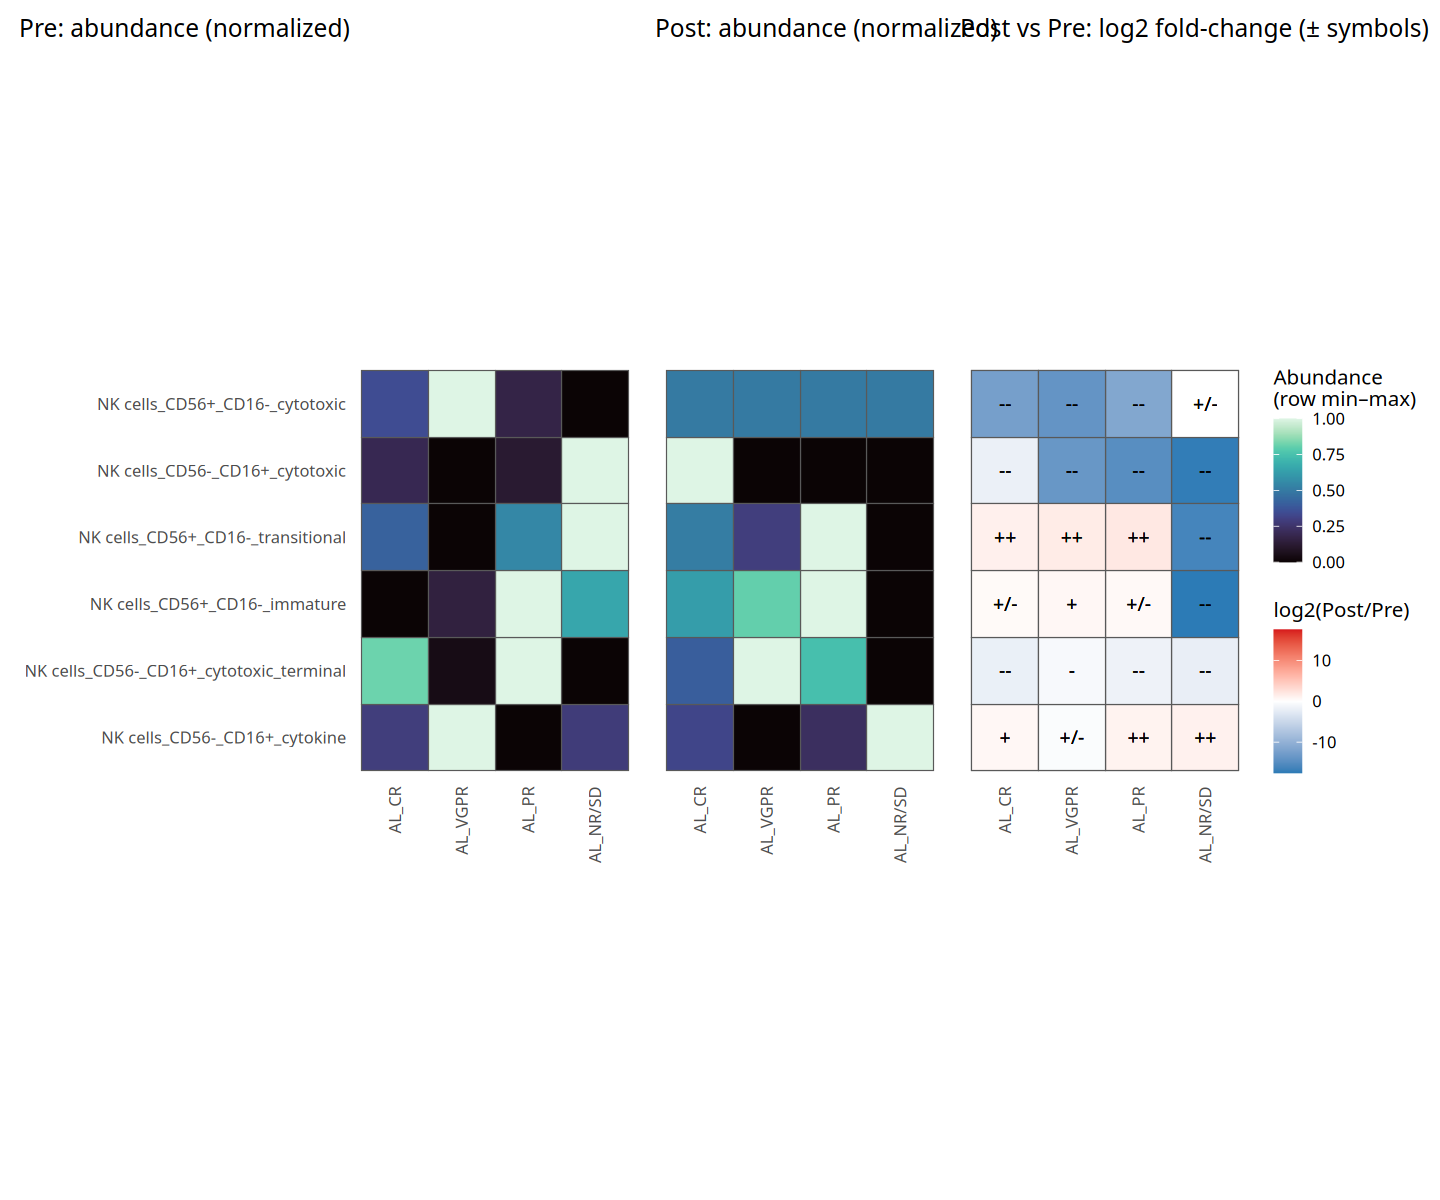

In [43]:
# --- after change_tbl is created (keep your previous wrangling) ---

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(patchwork)
  library(scales)
  library(viridis)
  library(viridisLite)
})

# Join LFC and symbols onto long table
frac_rtct2 <- frac_rtct %>%
  left_join(change_tbl %>% select(response, celltype, lfc, change_sym),
            by = c("response","celltype")) %>%
  mutate(
    response  = factor(response),
    celltype  = factor(celltype),
    treatment = factor(treatment, levels = c("Pre","Post"))
  )

# ---------------------------
# 1) Normalize abundance (pattern-focused)
#   - row-wise min-max within celltype x treatment
# ---------------------------
minmax01 <- function(x) {
  rng <- range(x, na.rm = TRUE)
  if (!all(is.finite(rng)) || diff(rng) == 0) return(rep(0.5, length(x)))
  (x - rng[1]) / (rng[2] - rng[1])
}

frac_rtct2 <- frac_rtct2 %>%
  group_by(celltype, treatment) %>%
  mutate(frac_norm = minmax01(frac)) %>%
  ungroup()

# ---------------------------
# 2) LFC cap (robust scale)
# ---------------------------
lfc_cap <- suppressWarnings(quantile(abs(frac_rtct2$lfc), 0.98, na.rm = TRUE))
if (!is.finite(lfc_cap) || lfc_cap == 0) {
  lfc_cap <- max(abs(frac_rtct2$lfc), na.rm = TRUE)
  if (!is.finite(lfc_cap) || lfc_cap == 0) lfc_cap <- 1
}

# ---------------------------
# 3) Paper-friendly MAK0 palette
#    Use viridisLite::mako to avoid version issues
# ---------------------------
mako_cols <- viridisLite::mako(256)

# ---------------------------
# Theme (vertical orientation)
# ---------------------------
vertical_theme <- theme_minimal(base_size = 12) +
  theme(
    axis.text.y  = element_text(angle = 0, hjust = 1, vjust = 0.5),
    axis.text.x  = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid   = element_blank(),
    plot.title.position = "plot"
  )

# ---------------------------
# 4) PRE normalized abundance heatmap (MAKO)
# ---------------------------
p_pre <- ggplot(
  subset(frac_rtct2, treatment == "Pre"),
  aes(x = response, y = celltype, fill = frac_norm)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradientn(
    name   = "Abundance\n(row min–max)",
    colors = mako_cols,
    limits = c(0, 1),
    oob    = scales::squish
  ) +
  coord_equal() +
  labs(title = "Pre: abundance (normalized)", x = NULL, y = NULL) +
  vertical_theme

# ---------------------------
# 5) POST normalized abundance heatmap (MAKO)
# ---------------------------
p_post <- ggplot(
  subset(frac_rtct2, treatment == "Post"),
  aes(x = response, y = celltype, fill = frac_norm)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradientn(
    name   = "Abundance\n(row min–max)",
    colors = mako_cols,
    limits = c(0, 1),
    oob    = scales::squish
  ) +
  coord_equal() +
  labs(title = "Post: abundance (normalized)", x = NULL, y = NULL) +
  vertical_theme +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank())

# ---------------------------
# 6) POST vs PRE (log2FC) with ± symbols (keep diverging for interpretability)
# ---------------------------
p_lfc <- ggplot(
  frac_rtct2,
  aes(x = response, y = celltype, fill = lfc)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradient2(
    name = "log2(Post/Pre)",
    low = "#2C7BB6", mid = "white", high = "#D7191C",
    midpoint = 0,
    limits = c(-lfc_cap, lfc_cap),
    oob = scales::squish
  ) +
  geom_text(
    data = subset(frac_rtct2, !is.na(change_sym)),
    aes(x = response, y = celltype, label = change_sym),
    inherit.aes = FALSE,
    color = "black", fontface = "bold", size = 4
  ) +
  coord_equal() +
  labs(title = "Post vs Pre: log2 fold-change (± symbols)", x = NULL, y = NULL) +
  vertical_theme +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank())

# ---------------------------
# 7) Combine horizontally
# ---------------------------
p_three <- (p_pre | p_post | p_lfc) +
  plot_layout(guides = "collect", widths = c(1, 1, 1)) &
  theme(legend.position = "right")

options(repr.plot.height = 10, repr.plot.width = 12)
print(p_three)


In [46]:
ggsave("Fig6b.pdf", plot = p_three, width = 10, height =12)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message 

In [36]:
# --- gene sets (same as your figure) ---
genes_inhib  <- c('KLRB1','TNFRSF18','KLRG1','TIGIT','KLRD1','CTLA4','HAVCR2','SIGLEC7','KLRD3','LILRB1','LILRB2','SIGLEC9')      # Inhibiting
genes_activ  <- c('KLRF1','FCGR3A','NCR3','ITGAL','CD2','CD226','NCR2','CD244','KLRK1','ICOS','CD96','TMIGD2','TNFRSF4','TNFRSF9','CD27','TNFRSF18') # Activating
genes_cytot  <- c('NKG7','GZMB','GNLY','FGFBP2','GZMH','PRF1','GZMA','FCGR3A','LAMP1','CST7','TNFSF10','FASLG')                  # Cytotoxicity
genes_cytok  <- c('CCL5','CCL4','CCL3','IFNG','TGFB1','IL10','IL1R1','IL1R2','IL15','IL16','IL18','IL32','CX3CR1','CXCR3','CXCR4','CXCR6','XCL1','XCL2','IL12RB2','CXCR6') # Cytokine



library(Seurat)
library(Matrix)

# Helper: per-cell mean on the log-normalized "data" slot
mean_score <- function(obj, genes, slot = "data") {
  g <- intersect(genes, rownames(obj))
  if (length(g) == 0) return(rep(NA_real_, ncol(obj)))
  mat <- GetAssayData(obj, slot = slot)[g, , drop = FALSE]
  Matrix::colMeans(mat)  # mean(log1p CPM) across the set
}

# Compute scores
sce1_nkcell$score_inhibiting   <- mean_score(sce1_nkcell, genes_inhib)
sce1_nkcell$score_activating   <- mean_score(sce1_nkcell, genes_activ)
sce1_nkcell$score_cytotoxicity <- mean_score(sce1_nkcell, genes_cytot)
sce1_nkcell$score_cytokine     <- mean_score(sce1_nkcell, genes_cytok)


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


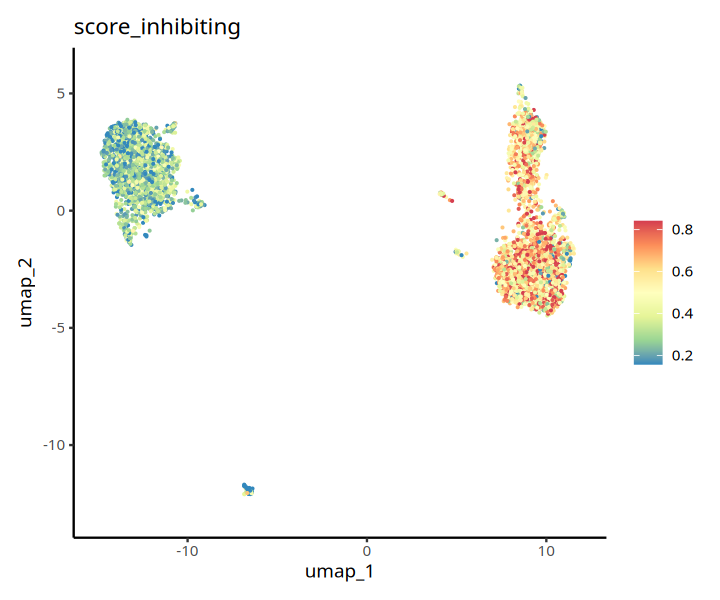

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


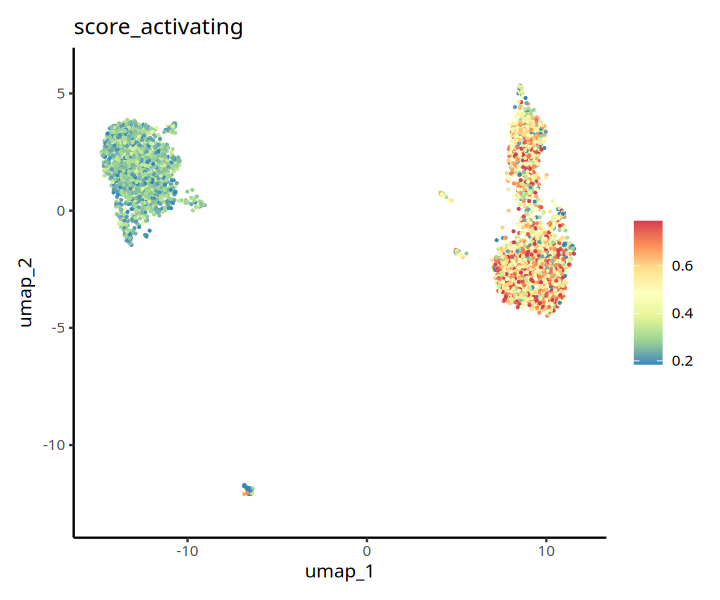

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


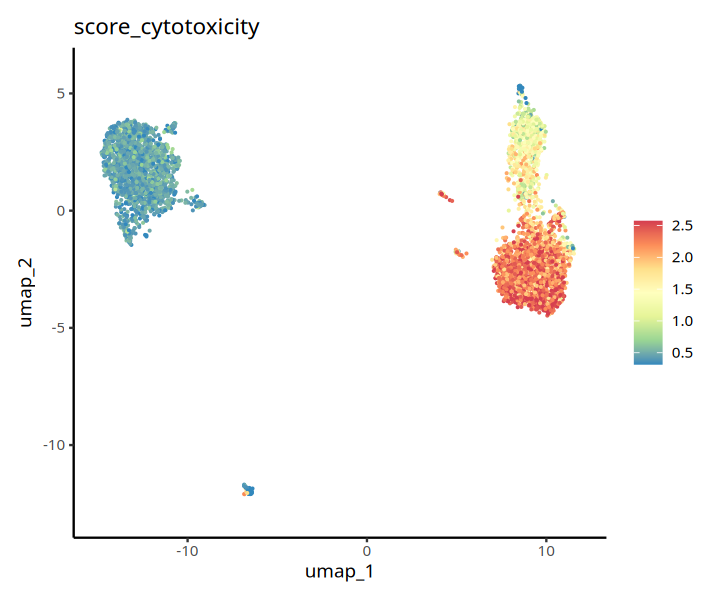

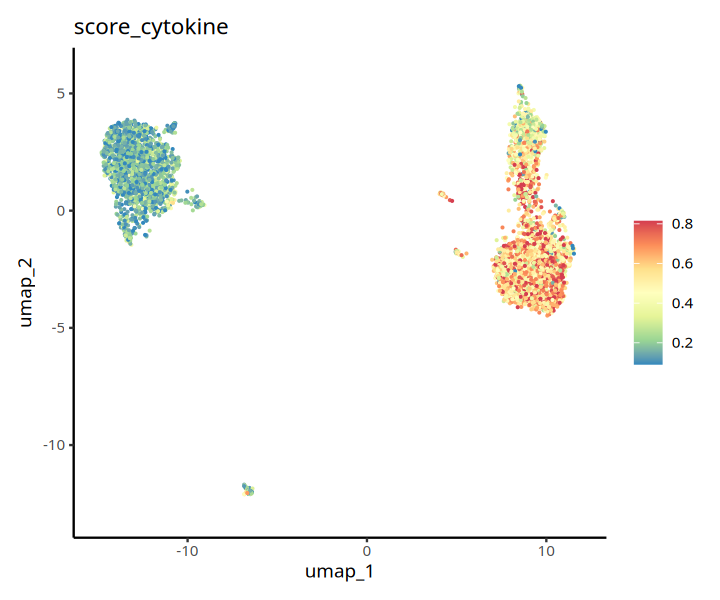

In [37]:
library(Seurat)
library(RColorBrewer)

options(repr.plot.height = 5, repr.plot.width = 6)

# --- Define color palette ---
spectral_colors <- brewer.pal(11, "Spectral")  # 11-step Spectral palette

# --- FeaturePlot with Spectral palette ---
FeaturePlot(
  sce1_nkcell,
  features = c("score_inhibiting"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()

FeaturePlot(
  sce1_nkcell,
  features = c( "score_activating"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()
FeaturePlot(
  sce1_nkcell,
  features = c("score_cytotoxicity"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()
FeaturePlot(
  sce1_nkcell,
  features = c("score_cytokine"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Centering and scaling data matrix



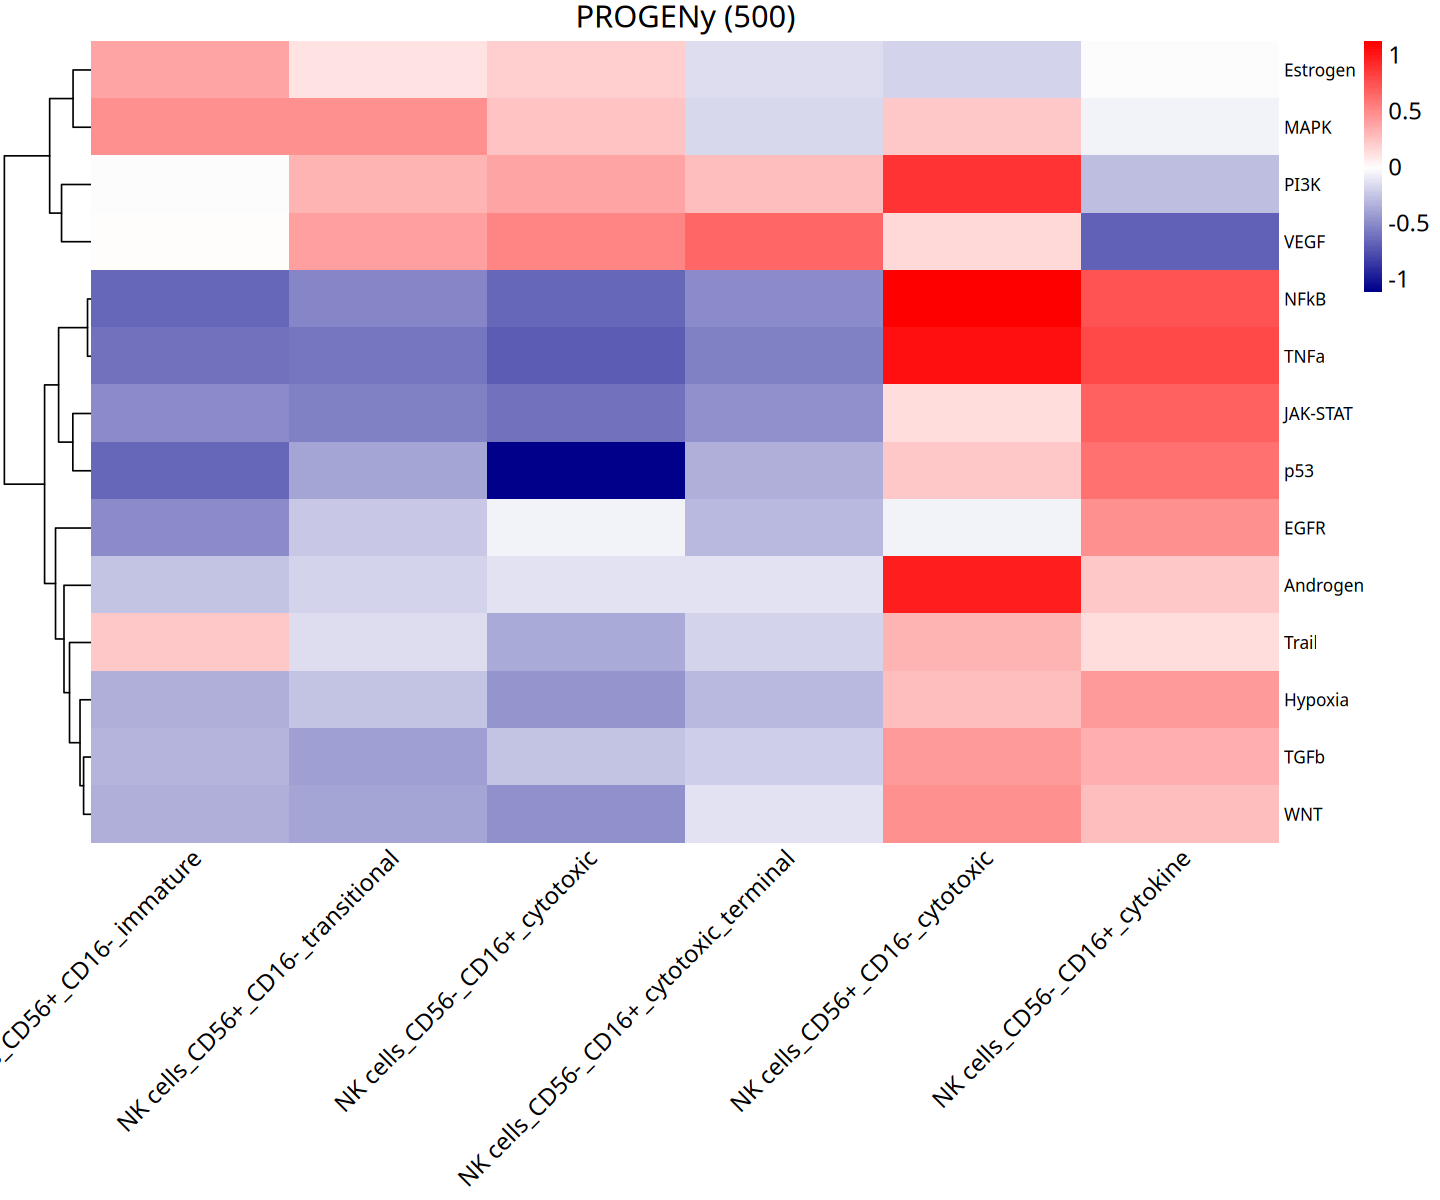

In [47]:
# ================== CONFIG ==================
obj <- sce1_nkcell                 # or sce1
assay_use <- DefaultAssay(obj)
layer_use <- "data"                # Seurat v5 uses 'layer'; v4 fallback handled below

celltype_col <- "Annotation"
treat_col    <- "treatment"        # "Pre","Post"
resp_col     <- "response"         # "CR","VGPR","PR","NR/SD", etc.

species      <- "Homo sapiens"

# ================== PACKAGES ==================
suppressPackageStartupMessages({
  library(Seurat)
  library(ggplot2)
  library(tidyr)
  library(readr)
  library(pheatmap)
  library(tibble)
  library(progeny)
  library(dplyr)
  library(rlang)
  library(tidyselect)
})

# ================== HELPERS ==================
map_species <- function(x) {
  if (grepl("human|sapiens", x, ignore.case = TRUE)) "Human" else "Mouse"
}

slot_exists <- function(seu, assay, slot_name) {
  # Works for Seurat v4/v5; returns TRUE if slot is available/non-null
  x <- tryCatch(GetAssayData(seu, assay = assay, slot = slot_name), error = function(e) NULL)
  !is.null(x)
}

# ================== 1) Ensure correct assay/slot and run PROGENy ==================
DefaultAssay(obj) <- assay_use
organism_tag <- map_species(species)

# choose slot to read from; fallback to "data" if requested layer missing
slot_to_use <- layer_use
if (!slot_exists(obj, assay_use, slot_to_use)) {
  message(sprintf("Requested slot '%s' not found; falling back to 'data'.", slot_to_use))
  slot_to_use <- "data"
}

# Run PROGENy; return a new "progeny" assay on the object
obj <- progeny(
  obj,
  scale         = FALSE,
  organism      = organism_tag,
  top           = 500,
  perm          = 1,
  return_assay  = TRUE,
  assay         = assay_use,
  slot          = slot_to_use
)

# Scale the PROGENy pathway activity scores
obj <- Seurat::ScaleData(obj, assay = "progeny")

# ================== 2) Build tidy scores + metadata ==================
# Get scaled matrix: rows = pathways, cols = cells
m_progeny <- GetAssayData(obj, assay = "progeny", slot = "scale.data")
pathways  <- rownames(m_progeny)

# cells x pathways data.frame with Cell column
progeny_scores_df <- t(m_progeny) %>%
  as.data.frame(check.names = FALSE)
progeny_scores_df$Cell <- rownames(progeny_scores_df)

# Attach meta
md <- obj@meta.data %>%
  tibble::rownames_to_column("Cell")

# ensure requested columns exist (add NA if missing)
for (nm in c(celltype_col, treat_col, resp_col)) {
  if (!nm %in% names(md)) md[[nm]] <- NA_character_
}

progeny_scores_df <- progeny_scores_df %>%
  dplyr::inner_join(md, by = "Cell")

# Long format: pivot ONLY the pathway columns
progeny_scores_long <- progeny_scores_df %>%
  tidyr::pivot_longer(
    cols = tidyselect::all_of(pathways),
    names_to = "Pathway", values_to = "Activity"
  )

# ================== 3) Summaries ==================
# A) By cell type
summ_ct_wide <- progeny_scores_long %>%
  dplyr::filter(!is.na(.data[[celltype_col]])) %>%
  dplyr::group_by(Pathway, !!rlang::sym(celltype_col)) %>%
  dplyr::summarise(avg = mean(Activity), .groups = "drop") %>%
  dplyr::rename(CellType = !!rlang::sym(celltype_col)) %>%
  tidyr::pivot_wider(names_from = Pathway, values_from = avg) %>%
  dplyr::arrange(CellType)

# B) By cell type × treatment (optional)
summ_ct_trt_wide <- progeny_scores_long %>%
  dplyr::filter(!is.na(.data[[celltype_col]]), !is.na(.data[[treat_col]])) %>%
  dplyr::group_by(Pathway, !!rlang::sym(celltype_col), !!rlang::sym(treat_col)) %>%
  dplyr::summarise(avg = mean(Activity), .groups = "drop") %>%
  dplyr::rename(CellType = !!rlang::sym(celltype_col), Treatment = !!rlang::sym(treat_col)) %>%
  tidyr::unite("CellType_Treat", CellType, Treatment, sep = " | ") %>%
  tidyr::pivot_wider(names_from = Pathway, values_from = avg) %>%
  dplyr::arrange(CellType_Treat)

# C) By cell type × response (optional)
summ_ct_resp_wide <- progeny_scores_long %>%
  dplyr::filter(!is.na(.data[[celltype_col]]), !is.na(.data[[resp_col]])) %>%
  dplyr::group_by(Pathway, !!rlang::sym(celltype_col), !!rlang::sym(resp_col)) %>%
  dplyr::summarise(avg = mean(Activity), .groups = "drop") %>%
  dplyr::rename(CellType = !!rlang::sym(celltype_col), Response = !!rlang::sym(resp_col)) %>%
  tidyr::unite("CellType_Response", CellType, Response, sep = " | ") %>%
  tidyr::pivot_wider(names_from = Pathway, values_from = avg) %>%
  dplyr::arrange(CellType_Response)

# ================== 4) Heatmap ==================
# Choose which summary to plot:
plot_mat <- summ_ct_wide
# plot_mat <- summ_ct_trt_wide
# plot_mat <- summ_ct_resp_wide

# Convert to matrix with explicit rowname column
first_col <- colnames(plot_mat)[1]  # e.g., "CellType" / "CellType_Treat" / "CellType_Response"
plot_df <- plot_mat %>%
  tibble::column_to_rownames(first_col) %>%
  as.matrix()

# Drop all-NA rows/cols gracefully
if (nrow(plot_df) == 0 || ncol(plot_df) == 0) {
  stop("No data to plot after summarization. Check filters and metadata columns.")
}
plot_df <- plot_df[rowSums(is.finite(plot_df)) > 0, , drop = FALSE]
plot_df <- plot_df[, colSums(is.finite(plot_df)) > 0, drop = FALSE]

paletteLength <- 100
myColor <- colorRampPalette(c("Darkblue", "white", "red"))(paletteLength)
rng <- range(plot_df, na.rm = TRUE)
progenyBreaks <- c(
  seq(rng[1], 0, length.out = ceiling(paletteLength/2) + 1),
  seq(max(1e-9, rng[2]) / paletteLength, rng[2], length.out = floor(paletteLength/2))
)

pheatmap::pheatmap(
  t(plot_df),
  fontsize       = 14,
  fontsize_row   = 10,
  color          = myColor,
  breaks         = progenyBreaks,
  main           = "PROGENy (500)",
  angle_col      = 45,
  treeheight_col = 0,
  border_color   = NA
)

# ================== 5) Objects you can reuse ==================
# - obj                 : Seurat object with 'progeny' assay (scaled)
# - progeny_scores_long : tidy (Cell, Pathway, Activity, + metadata)
# - summ_ct_wide        : CellType x Pathway mean activity
# - summ_ct_trt_wide    : CellType|Treatment x Pathway mean activity
# - summ_ct_resp_wide   : CellType|Response x Pathway mean activity


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NK subsets: PROGENy Δ (Post − Pre)' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NK subsets: PROGENy Δ (Post − Pre)' in 'mbcsToSbcs': dot substituted for <94>”
Warning me

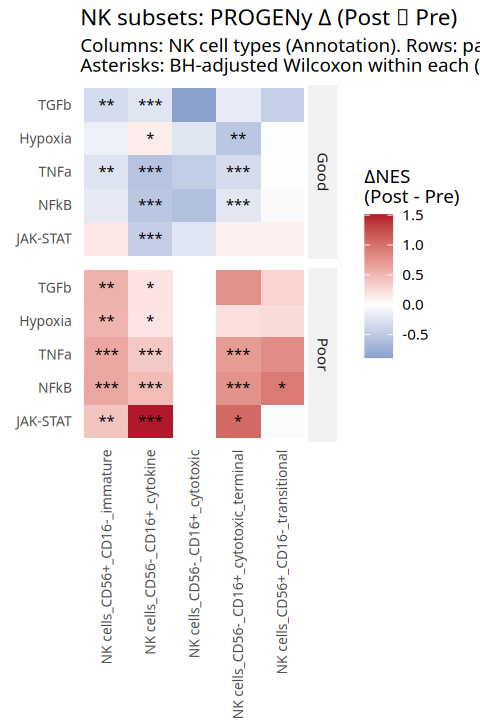

In [48]:
# ================== PROGENy Δ(Post - Pre) like ssGSEA ==================
library(dplyr)
library(tidyr)
library(rlang)
library(ggplot2)
library(scales)
library(tibble)
options(repr.plot.height = 6, repr.plot.width = 4)

# ---- user options ----
min_cells_per_group <- 3                         # >=3 cells per arm to test
exclude_pathways    <- c('Trail','VEGF','p53','PI3K','MAPK','EGFR','Estrogen','Androgen','WNT')           # e.g., c("Hypoxia","TGFb")
nk_order            <- unique(obj@meta.data[[celltype_col]])  # custom column order (optional)

# ---- helpers ----
zscore <- function(x) {
  s <- stats::sd(x, na.rm = TRUE)
  if (!is.finite(s) || s == 0) return(rep(0, length(x)))
  (x - mean(x, na.rm = TRUE)) / s
}
star_from_p <- function(p) {
  ifelse(is.na(p), "",
    ifelse(p < 0.001, "***",
      ifelse(p < 0.01, "**",
        ifelse(p < 0.05, "*", "")
      )
    )
  )
}

# ---- 1) Merge with metadata and collapse responses to Good/Poor ----
good_set <- c("AL_CR","AL_VGPR")
poor_set <- c("AL_PR","AL_NR/SD")

meta <- obj@meta.data %>%
  rownames_to_column("cell_id") %>%
  transmute(
    cell_id,
    Annotation = .data[[celltype_col]],
    treatment  = .data[[treat_col]],
    response   = .data[[resp_col]],
    resp_group = dplyr::case_when(
      response %in% good_set ~ "Good",
      response %in% poor_set ~ "Poor",
      TRUE ~ NA_character_
    )
  )

# progeny_scores_long columns expected: Cell, Pathway, Activity (+ metadata already added earlier)
long_df <- progeny_scores_long %>%
  select(Cell, Pathway, Activity) %>%
  rename(cell_id = Cell, pathway = Pathway, score_raw = Activity) %>%
  left_join(meta, by = "cell_id") %>%
  filter(!is.na(resp_group), !is.na(treatment), !is.na(Annotation)) %>%
  # optional: exclude some pathways from everything
  filter(if (length(exclude_pathways)) !(pathway %in% exclude_pathways) else TRUE)

# ---- 2) Convert to NES-like (z per pathway across ALL cells) ----
long_df <- long_df %>%
  group_by(pathway) %>%
  mutate(score_z = zscore(score_raw)) %>%
  ungroup()

# ---- 3) Wilcoxon Post vs Pre within (Annotation, resp_group, pathway) ----
stat_df <- long_df %>%
  group_by(Annotation, resp_group, pathway) %>%
  group_modify(~{
    dat <- .x
    n_pre  <- sum(dat$treatment == "Pre", na.rm = TRUE)
    n_post <- sum(dat$treatment == "Post", na.rm = TRUE)
    if (n_pre >= min_cells_per_group && n_post >= min_cells_per_group) {
      w <- suppressWarnings(wilcox.test(score_z ~ treatment, data = dat, exact = FALSE))
      tibble(
        n_pre = n_pre,
        n_post = n_post,
        mean_pre  = mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE),
        mean_post = mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE),
        deltaNES  = mean_post - mean_pre,
        p_value   = w$p.value
      )
    } else {
      tibble(
        n_pre = n_pre, n_post = n_post,
        mean_pre  = ifelse(n_pre>0,  mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE), NA_real_),
        mean_post = ifelse(n_post>0, mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE), NA_real_),
        deltaNES  = ifelse(n_pre>0 && n_post>0,
                           mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE) -
                           mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE), NA_real_),
        p_value   = NA_real_
      )
    }
  }) %>%
  ungroup() %>%
  # FDR within each pathway × Annotation across resp_groups
  group_by(pathway, Annotation) %>%
  mutate(padj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(star = star_from_p(padj)) %>%
  filter(!is.na(deltaNES))

# ---- 4) Ordering for plot ----
# Column order (cell types)
obs_nk <- stat_df %>% distinct(Annotation) %>% pull(Annotation)
levels_use <- if (length(nk_order) > 0) {
  c(intersect(nk_order, obs_nk), setdiff(sort(obs_nk), nk_order))
} else {
  sort(obs_nk)
}

# Pathway order by average deltaNES (desc)
pathway_levels <- stat_df %>%
  group_by(pathway) %>%
  summarise(avg_delta = mean(deltaNES, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(avg_delta)) %>%
  pull(pathway)

plot_df0 <- stat_df %>%
  mutate(
    Annotation = factor(Annotation, levels = levels_use),
    pathway    = factor(pathway, levels = pathway_levels),
    resp_group = factor(resp_group, levels = c("Good","Poor"))
  )

# ---- 5) Rotated heatmap: rows=pathways, columns=cell types, facets=Good/Poor ----
p <- ggplot(plot_df0, aes(x = Annotation, y = pathway, fill = deltaNES)) +
  geom_tile() +
  geom_text(aes(label = star), size = 3) +
  scale_fill_gradient2(
    name = "ΔNES\n(Post - Pre)",
    low = "#2166AC", mid = "white", high = "#B2182B", midpoint = 0
  ) +
  labs(
    x = NULL, y = NULL,
    title = "NK subsets: PROGENy Δ (Post − Pre)",
    subtitle = "Columns: NK cell types (Annotation). Rows: pathways. Facets: Good (AL_CR/AL_VGPR) vs Poor (AL_PR/AL_NR/SD).\nAsterisks: BH-adjusted Wilcoxon within each (Annotation, resp_group)."
  ) +
  facet_grid(resp_group ~ ., scales = "free_y", space = "free_y") +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    axis.text.y = element_text(size = 8),
    panel.grid = element_blank(),
    legend.position = "right",
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text = element_text(face = "bold")
  )

print(p)

# ---- 6) Optional: write out tables ----
# readr::write_csv(long_df, "progeny_long_scores.csv")
# readr::write_csv(stat_df, "progeny_post_vs_pre_delta.csv")

message(
  "N (Annotation × resp_group) tested: ",
  dplyr::n_distinct(interaction(stat_df$Annotation, stat_df$resp_group))
)
if (length(exclude_pathways)) {
  message("Excluded pathways: ", paste(exclude_pathways, collapse = ", "))
}


In [49]:
# ================== PACKAGES ==================
suppressPackageStartupMessages({
  library(Seurat)
  library(GSVA)
  library(msigdbr)
  library(dplyr)
  library(tidyr)
  library(Matrix)
  library(readr)
  library(tibble)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(purrr)
})

# ================== CONFIG ====================
obj <- sce1_nkcell                 # or sce1
assay_use <- DefaultAssay(obj)
layer_use <- "data"                # Seurat v5 uses 'layer'; v4 fallback handled below

celltype_col <- "Annotation"
treat_col    <- "treatment"        # "Pre","Post"
resp_col     <- "response"         # "CR","VGPR","PR","NR/SD", etc.

species      <- "Homo sapiens"

# Hallmark focus filter
focus_only   <- TRUE
focus_regex  <- "(INTERFERON)"

# Include C2/C7 categories relevant to NK ADCC / chemokine / exhaustion
include_C2_c7 <- TRUE

# OUTPUTS
out_dir <- "./ssgsea_by_cell_NES_heatmap_NK"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
out_sets_txt     <- file.path(out_dir, "gene_sets_used.txt")
out_scores_rds   <- file.path(out_dir, "ssgsea_scores_cells.rds")
out_long_csv     <- file.path(out_dir, "ssgsea_cell_long.csv.gz")
out_delta_csv    <- file.path(out_dir, "deltaNES_Post_vs_Pre_long.csv.gz")
out_heatmap_pdf  <- file.path(out_dir, "deltaNES_heatmap.pdf")
out_heatmap_png  <- file.path(out_dir, "deltaNES_heatmap.png")

# ================== HELPERS ==================
.get_assay_data <- function(object, assay, layer_or_slot = "data") {
  if ("layer" %in% names(formals(GetAssayData))) {
    GetAssayData(object, assay = assay, layer = layer_or_slot)
  } else {
    GetAssayData(object, assay = assay, slot  = layer_or_slot)
  }
}

zscore <- function(x) {
  mu <- mean(x, na.rm = TRUE); sdv <- sd(x, na.rm = TRUE)
  if (!is.finite(sdv) || sdv == 0) return(rep(0, length(x)))
  (x - mu) / sdv
}

star_from_p <- function(p) {
  ifelse(is.na(p), "",
    ifelse(p < 0.001, "***",
      ifelse(p < 0.01, "**",
        ifelse(p < 0.05, "*", ""))))
}

# ================== PATHWAYS ==================
# --- 1) Hallmark (H) ---
msig_H <- msigdbr(species = species, category = "H") %>%
  select(gs_name, gene_symbol, gs_cat = gs_cat) %>%
  { if (focus_only) dplyr::filter(., grepl(focus_regex, gs_name, ignore.case = TRUE)) else . }

# --- 2) C2 curated (Reactome/KEGG/BioCarta/PID) — NK ADCC, chemokine, exhaustion/checkpoints ---
msig_C2 <- tibble(gs_name = character(), gene_symbol = character(), gs_cat = character())
if (include_C2_c7) {
  C2_subcats <- c("CP:REACTOME","CP:KEGG")
  msig_C2_raw <- msigdbr(species = species, category = "C2") %>%
    filter(gs_subcat %in% C2_subcats)

  C2_regex <- paste(c(
    # ADCC / Fc receptors
    "NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY", "FCGR", "FCGAMMA",
    "FCERI", "FCE_RI", "FCER1", "ADCC"
  ), collapse = "|")

  msig_C2 <- msig_C2_raw %>%
    filter(grepl(C2_regex, gs_name, ignore.case = TRUE)) %>%
    select(gs_name, gene_symbol, gs_cat = gs_cat)
}

# --- 3) C7 immunologic signatures — NK activation, ADCC, exhaustion, IL2/IL15 ---
msig_C7 <- tibble(gs_name = character(), gene_symbol = character(), gs_cat = character())
if (include_C2_c7) {
  msig_C7_raw <- msigdbr(species = species, category = "C7")
  c7_regex <- paste(c(
    # ADCC / Fc receptors
    "NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY", "FCGR", "FCGAMMA",
    "FCERI", "FCE_RI", "FCER1", "ADCC"
  ), collapse = "|")

  msig_C7 <- msig_C7_raw %>%
    filter(grepl(c7_regex, gs_name, ignore.case = TRUE)) %>%
    select(gs_name, gene_symbol, gs_cat = gs_cat)
}

# --- Combine H + optional C2/C7, de-duplicate rows, then split ---
msig_all <- bind_rows(msig_H, msig_C2, msig_C7) %>%
  distinct(gs_name, gene_symbol)  # <-- FIX: dedupe in row space, not via mutate()

# Split to pathways list
pathways_list <- split(msig_all$gene_symbol, msig_all$gs_name)

# Save gene sets used (names + members)
writeLines(
  unlist(lapply(names(pathways_list), function(nm) {
    c(paste0("### ", nm), paste(sort(unique(pathways_list[[nm]])), collapse = ", "), "")
  })), con = out_sets_txt
)

stopifnot(length(pathways_list) > 0)

# ================== EXPRESSION (genes x cells) ==================
md <- obj@meta.data %>% as.data.frame()
stopifnot(all(c(celltype_col, treat_col, resp_col) %in% colnames(md)))

E <- .get_assay_data(obj, assay = assay_use, layer_or_slot = layer_use)

# Intersect genes with any set; drop tiny sets (<5 genes) after intersection
genes_keep <- intersect(rownames(E), unique(unlist(pathways_list)))
E <- E[genes_keep, , drop = FALSE]
pathways_list <- lapply(pathways_list, function(v) intersect(v, rownames(E)))
pathways_list <- pathways_list[sapply(pathways_list, length) >= 5]
stopifnot(length(pathways_list) > 0)

# ================== RUN ssGSEA PER CELL ==================
set.seed(1)
ssm <- gsva(as.matrix(E), pathways_list, method = "ssgsea",
            kcdf = "Gaussian", abs.ranking = TRUE, parallel.sz = 1)  # pathways x cells
saveRDS(ssm, out_scores_rds)

# ================== MERGE WITH METADATA ==================
cell_ids <- colnames(E)
meta <- md[match(cell_ids, rownames(md)), , drop = FALSE]
meta$cell_id <- cell_ids

long_df <- as.data.frame(t(ssm)) %>%
  rownames_to_column("cell_id") %>%
  left_join(meta %>%
              transmute(cell_id,
                        Annotation = .data[[celltype_col]],
                        treatment  = .data[[treat_col]],
                        response   = .data[[resp_col]]),
            by = "cell_id") %>%
  pivot_longer(cols = -c(cell_id, Annotation, treatment, response),
               names_to = "pathway", values_to = "score_raw")

# ================== CONVERT TO NES-like (z per pathway across ALL cells) ==================
long_df <- long_df %>%
  group_by(pathway) %>%
  mutate(score_z = zscore(score_raw)) %>%
  ungroup()

# Save per-cell long scores
readr::write_csv(long_df, out_long_csv)

# ================== STAT TEST: Post vs Pre within each (Annotation, response, pathway) ==================
min_cells_per_group <- 3  # at least 3 cells per arm to test

stat_df <- long_df %>%
  group_by(Annotation, response, pathway) %>%
  group_modify(~{
    dat <- .x
    n_pre  <- sum(dat$treatment == "Pre", na.rm = TRUE)
    n_post <- sum(dat$treatment == "Post", na.rm = TRUE)
    if (n_pre >= min_cells_per_group && n_post >= min_cells_per_group) {
      w <- suppressWarnings(wilcox.test(score_z ~ treatment, data = dat, exact = FALSE))
      tibble(
        n_pre = n_pre, n_post = n_post,
        mean_pre  = mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE),
        mean_post = mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE),
        deltaNES  = mean_post - mean_pre,
        p_value   = w$p.value
      )
    } else {
      tibble(
        n_pre = n_pre, n_post = n_post,
        mean_pre  = ifelse(n_pre>0,  mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE), NA_real_),
        mean_post = ifelse(n_post>0, mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE), NA_real_),
        deltaNES  = ifelse(n_pre>0 && n_post>0,
                           mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE) -
                           mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE), NA_real_),
        p_value   = NA_real_
      )
    }
  }) %>%
  ungroup() %>%
  group_by(pathway, Annotation) %>%
  mutate(padj = p.adjust(p_value, method = "BH")) %>%   # FDR within each pathway×Annotation
  ungroup() %>%
  mutate(star = star_from_p(padj)) %>%
  filter(!is.na(deltaNES))

readr::write_csv(stat_df, out_delta_csv)

# ================== HEATMAP DATA ==================
stat_df <- stat_df %>%
  mutate(col_label = paste0(Annotation, " | ", response, " (Post vs Pre)"))

col_levels <- stat_df %>%
  distinct(Annotation, response) %>%
  arrange(Annotation, response) %>%
  transmute(lab = paste0(Annotation, " | ", response, " (Post vs Pre)")) %>%
  pull(lab)

plot_df <- stat_df %>%
  mutate(
    col_label = factor(col_label, levels = col_levels),
    pathway   = forcats::fct_reorder(pathway, deltaNES, .fun = function(x) mean(x, na.rm = TRUE))
  )

# ================== SUMMARY ==================
message("Gene set counts — H: ", length(unique(msig_H$gs_name)),
        " | C2 sel: ", length(unique(msig_C2$gs_name)),
        " | C7 sel: ", length(unique(msig_C7$gs_name)))
message("N groups (Annotation x response) tested: ", n_distinct(plot_df$col_label))


Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“139 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 18 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Gene set counts — H: 2 | C2 sel: 8 | C7 sel: 8

N groups (Annotation x response) tested: 15



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔNES' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NK subsets: ssGSEA NES Δ (Post vs Pre)' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NK subsets: ssGSEA NES Δ (Post vs Pre)' in 'mbcsToSbcs': dot substituted for <94>”
Wa

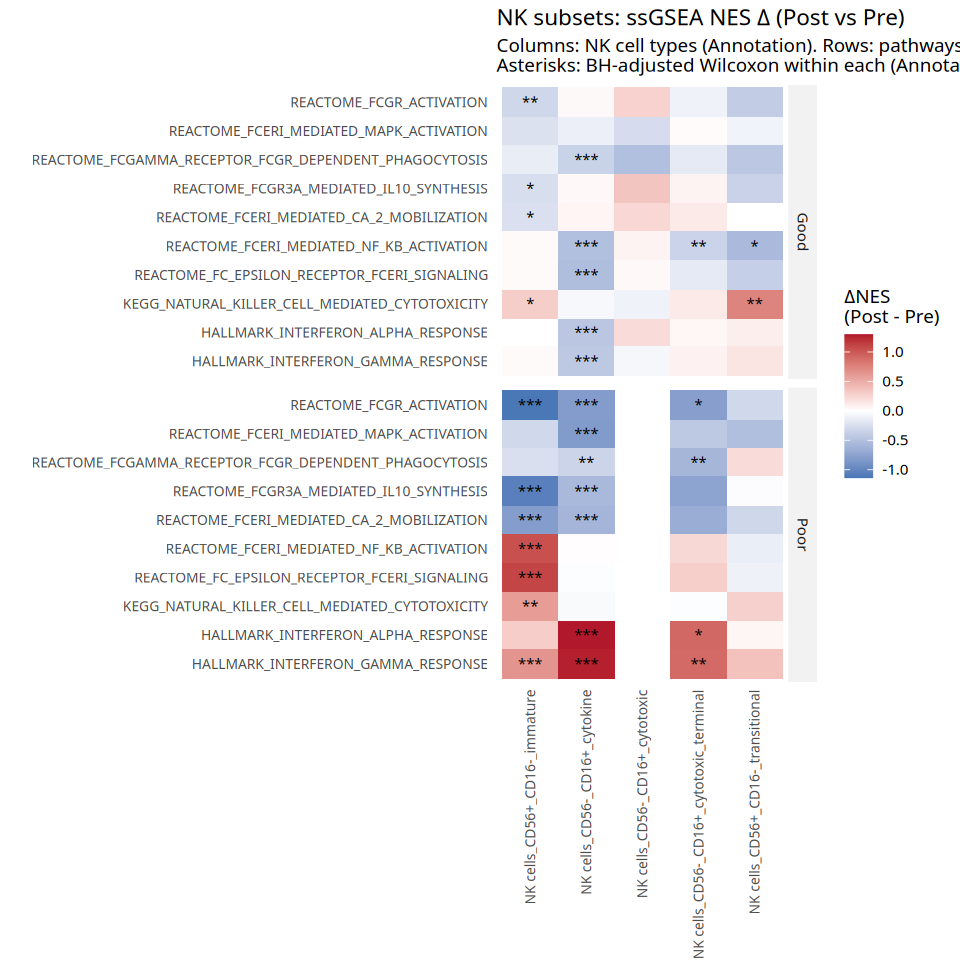

In [50]:
options(repr.plot.height = 8, repr.plot.width = 8)
# ================== MERGE WITH METADATA (add Good/Poor) ==================
cell_ids <- colnames(E)
meta <- md[match(cell_ids, rownames(md)), , drop = FALSE]
meta$cell_id <- cell_ids

# Map responses -> Good / Poor
good_set <- c("AL_CR","AL_VGPR")
poor_set <- c("AL_PR","AL_NR/SD")

meta <- meta %>%
  mutate(
    resp_group = case_when(
      .data[[resp_col]] %in% good_set ~ "Good",
      .data[[resp_col]] %in% poor_set ~ "Poor",
      TRUE ~ NA_character_
    )
  )

long_df <- as.data.frame(t(ssm)) %>%
  rownames_to_column("cell_id") %>%
  left_join(meta %>%
              transmute(cell_id,
                        Annotation = .data[[celltype_col]],
                        treatment  = .data[[treat_col]],
                        response   = .data[[resp_col]],
                        resp_group),
            by = "cell_id") %>%
  filter(!is.na(resp_group)) %>%      # keep Good/Poor only
  pivot_longer(cols = -c(cell_id, Annotation, treatment, response, resp_group),
               names_to = "pathway", values_to = "score_raw")

# ================== CONVERT TO NES-like (z per pathway across ALL cells) ==================
long_df <- long_df %>%
  group_by(pathway) %>%
  mutate(score_z = zscore(score_raw)) %>%
  ungroup()

readr::write_csv(long_df, out_long_csv)

# ================== STAT TEST: Post vs Pre within (Annotation, resp_group, pathway) ==================
min_cells_per_group <- 3  # at least 3 cells per arm to test

stat_df <- long_df %>%
  group_by(Annotation, resp_group, pathway) %>%
  group_modify(~{
    dat <- .x
    n_pre  <- sum(dat$treatment == "Pre", na.rm = TRUE)
    n_post <- sum(dat$treatment == "Post", na.rm = TRUE)
    if (n_pre >= min_cells_per_group && n_post >= min_cells_per_group) {
      w <- suppressWarnings(wilcox.test(score_z ~ treatment, data = dat, exact = FALSE))
      tibble(
        n_pre = n_pre, n_post = n_post,
        mean_pre  = mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE),
        mean_post = mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE),
        deltaNES  = mean_post - mean_pre,
        p_value   = w$p.value
      )
    } else {
      tibble(
        n_pre = n_pre, n_post = n_post,
        mean_pre  = ifelse(n_pre>0,  mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE), NA_real_),
        mean_post = ifelse(n_post>0, mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE), NA_real_),
        deltaNES  = ifelse(n_pre>0 && n_post>0,
                           mean(dat$score_z[dat$treatment=="Post"], na.rm = TRUE) -
                           mean(dat$score_z[dat$treatment=="Pre"],  na.rm = TRUE), NA_real_),
        p_value   = NA_real_
      )
    }
  }) %>%
  ungroup() %>%
  # FDR within pathway × Annotation across the two resp_groups
  group_by(pathway, Annotation) %>%
  mutate(padj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(star = star_from_p(padj)) %>%
  filter(!is.na(deltaNES))

readr::write_csv(stat_df, out_delta_csv)

# ================== HEATMAP DATA (rows=NK types, cols=pathways, facets=Good/Poor) ==================
# ---- Optional: specify your preferred NK order here ----
nk_order <- unique(sce1_nkcell@meta.data$Annotation)

# Build the levels: use your custom order first (if provided), then append any remaining labels
obs_nk <- stat_df %>% distinct(Annotation) %>% pull(Annotation)
levels_use <- if (length(nk_order) > 0) {
  c(intersect(nk_order, obs_nk), setdiff(sort(obs_nk), nk_order))
} else {
  sort(obs_nk)  # fallback: alphabetical
}

# Optional: order pathways by average deltaNES (within each facet the order will be the same)
pathway_levels <- stat_df %>%
  group_by(pathway) %>%
  summarise(avg_delta = mean(deltaNES, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(avg_delta)) %>%
  pull(pathway)

plot_df <- stat_df %>%
  mutate(
    Annotation = factor(Annotation, levels = levels_use),
    pathway    = factor(pathway, levels = pathway_levels),
    resp_group = factor(resp_group, levels = c("Good","Poor"))
  )

plot_df2 <- plot_df %>%
  filter(!grepl("GSE", pathway, ignore.case = TRUE))

# ================== ROTATED HEATMAP (rows = pathways, columns = NK cell types) ==================
p <- ggplot(plot_df2, aes(x = Annotation, y = pathway, fill = deltaNES)) +
  geom_tile() +
  geom_text(aes(label = star), size = 3) +
  scale_fill_gradient2(name = "ΔNES\n(Post - Pre)",
                       low = "#2166AC", mid = "white", high = "#B2182B", midpoint = 0) +
  labs(x = NULL, y = NULL,
       title = "NK subsets: ssGSEA NES Δ (Post vs Pre)",
       subtitle = "Columns: NK cell types (Annotation). Rows: pathways. Facets: Good (CR/VGPR) vs Poor (PR/NR/SD).\nAsterisks: BH-adjusted Wilcoxon within each (Annotation, resp_group).") +
  facet_grid(resp_group ~ ., scales = "free_y", space = "free_y") +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    axis.text.y = element_text(size = 8),
    panel.grid = element_blank(),
    legend.position = "right",
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text = element_text(face = "bold")
  )

# Save as PDF and PNG
ggsave(out_heatmap_pdf, p, width = 9, height = 12, limitsize = FALSE, useDingbats = FALSE)
ggsave(out_heatmap_png, p, width = 9, height = 12, dpi = 300, limitsize = FALSE)
print(p)

message("N (Annotation × resp_group) tested: ", n_distinct(interaction(plot_df$Annotation, plot_df$resp_group)))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <a2>

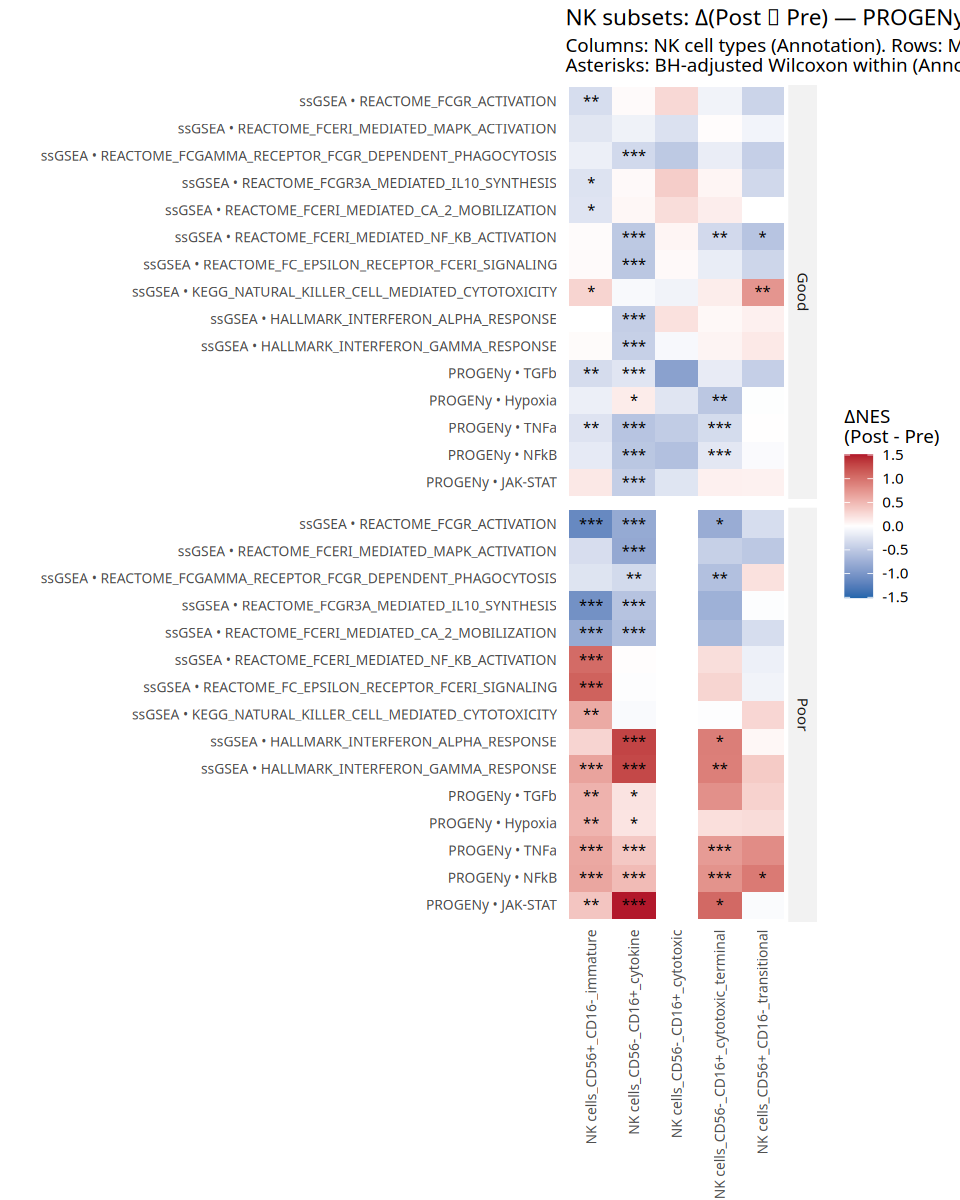

In [51]:
# ================== ONE PLOT: stack PROGENy + ssGSEA rows, facet by Good/Poor ==================
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(forcats)

options(repr.plot.height = 10, repr.plot.width = 8)

# Inputs expected:
#   plot_df0 : PROGENy table with (Annotation, pathway, resp_group, deltaNES, star)
#   plot_df2 : ssGSEA  table with same columns

# 1) Tag method & bind
df_prog <- plot_df0 %>%
  mutate(Method = "PROGENy") %>%
  select(Method, Annotation, pathway, resp_group, deltaNES, star)

df_ssg  <- plot_df2 %>%
  mutate(Method = "ssGSEA") %>%
  select(Method, Annotation, pathway, resp_group, deltaNES, star)

df_all <- bind_rows(df_prog, df_ssg) %>%
  mutate(resp_group = factor(resp_group, levels = c("Good","Poor")),
         Method = factor(Method, levels = c("PROGENy","ssGSEA")))

# 2) Build a combined y label: "METHOD • pathway"
df_all <- df_all %>%
  mutate(pathway_method = paste(Method, pathway, sep = " • "))

# 3) Consistent ordering
# Columns (NK types): use your custom nk_order if defined, else by |ΔNES|
if (exists("nk_order") && length(nk_order) > 0) {
  ann_lvls <- nk_order
} else {
  ann_lvls <- df_all %>%
    group_by(Annotation) %>% summarise(m = mean(abs(deltaNES), na.rm = TRUE), .groups="drop") %>%
    arrange(desc(m)) %>% pull(Annotation)
}
df_all <- df_all %>% mutate(Annotation = factor(Annotation, levels = ann_lvls))

# Rows (pathway_method): order within each Method, then keep PROGENy block above ssGSEA
ord_tbl <- df_all %>%
  group_by(Method, pathway) %>%
  summarise(m = mean(deltaNES, na.rm = TRUE), .groups = "drop") %>%
  group_by(Method) %>% arrange(desc(m), .by_group = TRUE) %>%
  mutate(pathway_method = paste(Method, pathway, sep = " • "))

row_levels <- ord_tbl %>%
  arrange(factor(Method, levels = c("PROGENy","ssGSEA")), desc(m)) %>%
  pull(pathway_method)

df_all <- df_all %>%
  mutate(pathway_method = factor(pathway_method, levels = row_levels))

# 4) Shared symmetric color scale across both methods
lim <- max(abs(range(df_all$deltaNES, na.rm = TRUE)))
if (!is.finite(lim) || lim == 0) lim <- 1e-6

# 5) Plot: one panel per Good/Poor; rows = METHOD•pathway, cols = NK types
p_one <- ggplot(df_all, aes(x = Annotation, y = pathway_method, fill = deltaNES)) +
  geom_tile() +
  geom_text(aes(label = star), size = 3) +
  scale_fill_gradient2(
    name = "ΔNES\n(Post - Pre)",
    low = "#2166AC", mid = "white", high = "#B2182B",
    midpoint = 0, limits = c(-lim, lim), oob = squish
  ) +
  labs(
    x = NULL, y = NULL,
    title = "NK subsets: Δ(Post − Pre) — PROGENy and ssGSEA combined",
    subtitle = "Columns: NK cell types (Annotation). Rows: METHOD • pathway. Facets: Good vs Poor.\nAsterisks: BH-adjusted Wilcoxon within (Annotation, resp_group)."
  ) +
  facet_grid(resp_group ~ ., scales = "free_y", space = "free_y") +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    axis.text.y = element_text(size = 8),
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text = element_text(face = "bold"),
    legend.position = "right"
  )

print(p_one)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <a2>

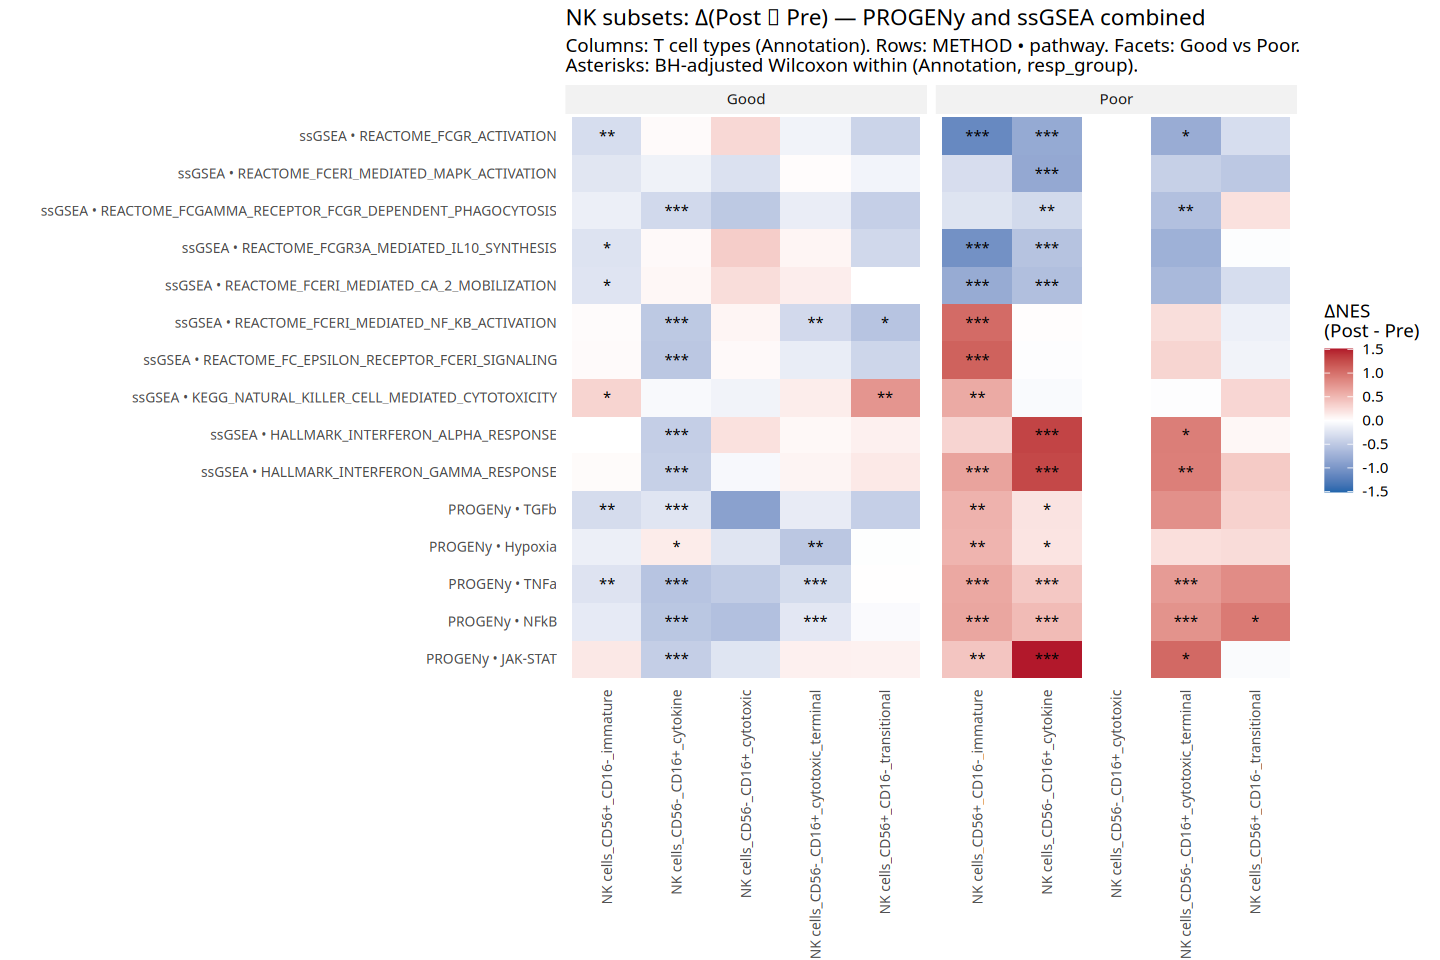

In [52]:
# make facets as columns
options(repr.plot.height = 8, repr.plot.width = 12)

p_one <- ggplot(df_all, aes(x = Annotation, y = pathway_method, fill = deltaNES)) +
  geom_tile() +
  geom_text(aes(label = star), size = 3) +
  scale_fill_gradient2(
    name = "ΔNES\n(Post - Pre)",
    low = "#2166AC", mid = "white", high = "#B2182B",
    midpoint = 0, limits = c(-lim, lim), oob = squish
  ) +
  labs(
    x = NULL, y = NULL,
    title = "NK subsets: Δ(Post − Pre) — PROGENy and ssGSEA combined",
    subtitle = "Columns: T cell types (Annotation). Rows: METHOD • pathway. Facets: Good vs Poor.\nAsterisks: BH-adjusted Wilcoxon within (Annotation, resp_group)."
  ) +
  facet_grid(. ~ resp_group, scales = "free_y", space = "free_y") +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    axis.text.y = element_text(size = 8),
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text = element_text(face = "bold"),
    strip.placement = "outside",
    legend.position = "right"
  )
print(p_one)

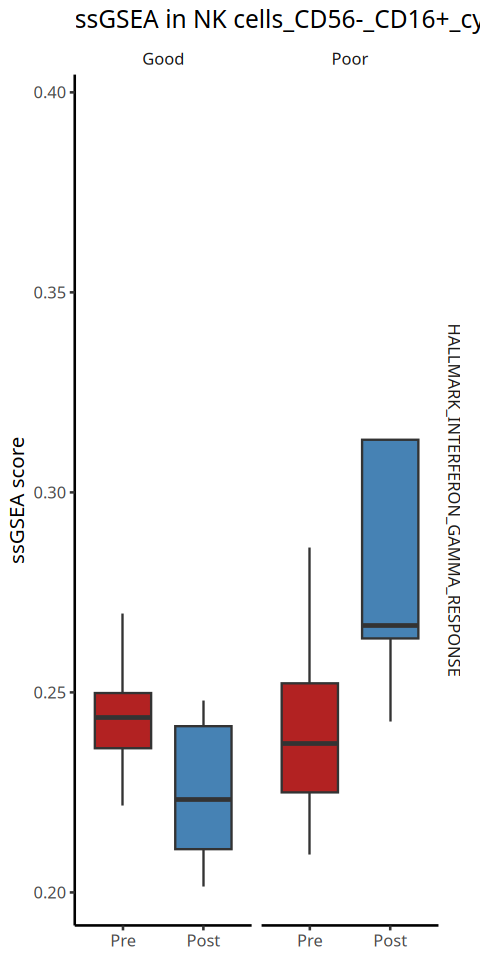

In [54]:
# ================== ssGSEA -> tidy -> boxplots (Pre vs Post in Good/Poor) ==================

suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(forcats); library(stringr); library(tibble)
})

# ---- Inputs assumed available from your script ----
# obj  : Seurat object with meta (Annotation/treatment/response/etc.)
# md   : obj@meta.data as data.frame
# ssm  : ssGSEA score matrix (pathways x cells), already saved as out_scores_rds
# celltype_col, treat_col, resp_col, resp_lvls, tx_lvls should be defined above, else set defaults here.

if (!exists("resp_lvls")) resp_lvls <- c("AL_CR","AL_VGPR","AL_PR","AL_NR/SD")
if (!exists("tx_lvls"))   tx_lvls   <- c("Pre","Post")
if (!exists("celltype_col")) celltype_col <- "Annotation"
if (!exists("treat_col"))    treat_col    <- "treatment"
if (!exists("resp_col"))     resp_col     <- "response"

# Use the matrix already in memory; otherwise read it
if (!exists("ssm")) ssm <- readRDS(out_scores_rds)  # pathways x cells

# ================== KNOBS ==================

target_celltype <- "NK cells_CD56-_CD16+_cytokine"    # pick your cell type
pathways_in     <- c("HALLMARK_INTERFERON_GAMMA_RESPONSE")                            # e.g. c("HALLMARK_INTERFERON_ALPHA_RESPONSE")
n_path_auto     <- 6                                 # if pathways_in is NULL, show first N present
z_per_pathway   <- FALSE                             # TRUE = z-score each pathway across cells
tx_cols         <- c(Pre = "firebrick", Post = "steelblue")

# ================== Tidy the ssGSEA scores and join meta ==================
stopifnot(ncol(obj) == ncol(ssm))
stopifnot(all(colnames(ssm) == colnames(obj)))  # keep 1:1 mapping

# scores long: Cell, Pathway, score
ssgsea_long <- ssm %>%
  t() %>%                                # cells x pathways
  as.data.frame(check.names = FALSE) %>%
  rownames_to_column("Cell") %>%
  pivot_longer(-Cell, names_to = "Pathway", values_to = "score")

# attach meta
meta_use <- obj@meta.data %>% rownames_to_column("Cell")
ssgsea_long <- ssgsea_long %>%
  inner_join(meta_use, by = "Cell") %>%
  mutate(
    !!treat_col := factor(.data[[treat_col]], levels = tx_lvls),
    !!resp_col  := factor(.data[[resp_col]],  levels = resp_lvls),
    resp_group  = case_when(
      .data[[resp_col]] %in% c("AL_CR","AL_VGPR")   ~ "Good",
      .data[[resp_col]] %in% c("AL_PR","AL_NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),
    resp_group  = factor(resp_group, levels = c("Good","Poor"))
  ) %>%
  filter(!is.na(resp_group), !is.na(.data[[treat_col]]))

# optional z-score per pathway (across all cells kept)
if (isTRUE(z_per_pathway)) {
  ssgsea_long <- ssgsea_long %>%
    group_by(Pathway) %>%
    mutate(score = {
      mu <- mean(score, na.rm = TRUE); sdv <- sd(score, na.rm = TRUE)
      if (!is.finite(sdv) || sdv == 0) 0 else (score - mu)/sdv
    }) %>%
    ungroup()
}

# Focus one cell type
ssgsea_ct <- ssgsea_long %>% filter(.data[[celltype_col]] == target_celltype)
stopifnot(nrow(ssgsea_ct) > 0)

# Choose pathways
if (!is.null(pathways_in)) {
  ssgsea_ct <- ssgsea_ct %>% filter(Pathway %in% pathways_in)
} else {
  top_paths <- ssgsea_ct %>% distinct(Pathway) %>% slice_head(n = n_path_auto) %>% pull(Pathway)
  ssgsea_ct <- ssgsea_ct %>% filter(Pathway %in% top_paths)
}
ssgsea_ct <- ssgsea_ct %>% mutate(Pathway = fct_inorder(Pathway))

# Try to find a sample/subject column for per-sample means
id_candidates <- c("sample_id","orig.ident","specimen_id","library_id","patient_id","subject_id")
id_col <- intersect(id_candidates, colnames(ssgsea_ct))
id_col <- if (length(id_col)) id_col[1] else NA_character_

# ================== PLOTTING (match PTGS2 style) ==================
options(repr.plot.height = 8, repr.plot.width = 4)

if (!is.na(id_col)) {
  # ---- Per-sample means (recommended) ----
  plot_means <- ssgsea_ct %>%
    group_by(.data[[id_col]], resp_group, .data[[treat_col]], Pathway) %>%
    summarise(mean_score = mean(score, na.rm = TRUE), .groups = "drop")

  p <- ggplot(plot_means, aes(x = .data[[treat_col]], y = mean_score, fill = .data[[treat_col]])) +
    geom_boxplot(width = 0.7, outlier.shape = NA) +
    scale_fill_manual(values = tx_cols, guide = "none") +
    facet_grid(rows = vars(Pathway), cols = vars(resp_group), scales = "free_y", space = "free_x") +
    theme_classic(base_size = 12) +
    labs(
      x = NULL,
      y = if (z_per_pathway) "ssGSEA (z-score, per pathway)" else "ssGSEA score",
      title = paste0("ssGSEA in ", target_celltype, " (Pre vs Post by Good/Poor)")
    ) +
    theme(
      axis.text.x      = element_text(angle = 0, hjust = 0.5),
      strip.background = element_blank(),
      strip.text       = element_text(face = "bold")
    )

} else {
  # ---- No sample ID: show group means ±95% CI (per-cell) ----
  summary_df <- ssgsea_ct %>%
    group_by(resp_group, .data[[treat_col]], Pathway) %>%
    summarise(
      n  = dplyr::n(),
      mu = mean(score, na.rm = TRUE),
      sd = sd(score, na.rm = TRUE),
      se = sd / sqrt(n),
      ci = 1.96 * se,
      .groups = "drop"
    )

  p <- ggplot(summary_df, aes(x = resp_group, y = mu, fill = .data[[treat_col]])) +
    geom_col(position = position_dodge(width = 0.7), width = 0.6) +
    geom_errorbar(aes(ymin = mu - ci, ymax = mu + ci),
                  position = position_dodge(width = 0.7), width = 0.3) +
    scale_fill_manual(values = tx_cols) +
    facet_wrap(~ Pathway, ncol = 2, scales = "free_y") +
    theme_classic(base_size = 12) +
    labs(
      x = NULL,
      y = if (z_per_pathway) "ssGSEA (z-score, per pathway)" else "ssGSEA score (mean ±95% CI)",
      title = paste0("ssGSEA in ", target_celltype, " (Good/Poor; Pre/Post)")
    ) +
    theme(
      axis.text.x      = element_text(angle = 0, hjust = 0.5),
      strip.background = element_blank(),
      strip.text       = element_text(face = "bold")
    )
}

print(p)


In [57]:
ggsave("Fig6f.pdf", plot = p_one, width = 10, height =5)
ggsave("Fig6e.pdf", plot = p, width = 4, height =3)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <a2>

In [61]:
Idents(sce1_nkcell)<-'Annotation'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene<- c(
"CD38",'PTGS2','PTGER2','PTGER4','PTGES2','PTGES3','KLRK1','LILRB1','HCST'
) 


In [66]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_nkcell, features = unique(allgene), split.by = "Annotation", scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


In [76]:
unique(plot_data$id)

[1] NK cells_CD56+_CD16-_immature_NK cells_CD56+_CD16-_immature                    
[2] NK cells_CD56-_CD16+_cytokine_NK cells_CD56-_CD16+_cytokine                    
[3] NK cells_CD56-_CD16+_cytotoxic_NK cells_CD56-_CD16+_cytotoxic                  
[4] NK cells_CD56-_CD16+_cytotoxic_terminal_NK cells_CD56-_CD16+_cytotoxic_terminal
[5] NK cells_CD56+_CD16-_transitional_NK cells_CD56+_CD16-_transitional            
[6] NK cells_CD56+_CD16-_cytotoxic_NK cells_CD56+_CD16-_cytotoxic                  
6 Levels: NK cells_CD56-_CD16+_cytokine_NK cells_CD56-_CD16+_cytokine ...

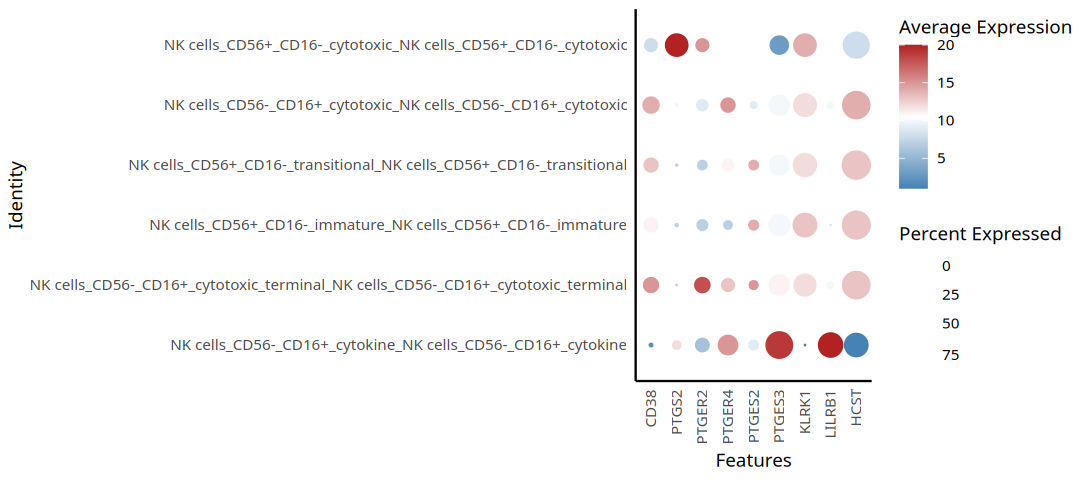

In [79]:
# 1) Define the exact order you want (top -> bottom)
row_order <- rev(unique(plot_data$id)[c(6,3,5,1,4,2)])
# 2) Apply it (this controls ggplot row order)
plot_data$id <- factor(plot_data$id, levels = row_order)

# 3) Plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled),
             shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [83]:
ggsave("Fig6c.pdf", plot = p, width = 9, height =4)